### Imports e iniciando cessão com o S3

In [10]:
import pandas as pd 
import boto3 

from dotenv import load_dotenv
from datetime import datetime
from src.data.utils import *

load_dotenv()

True

In [11]:
session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")


In [13]:
def listar_apenas_pastas(s3_client, bucket: str):
    paginator = s3_client.get_paginator('list_objects_v2')
    todas_pastas = set()

    for page in paginator.paginate(Bucket=bucket):
        for obj in page.get('Contents', []):
            partes = obj['Key'].split('/')
            if len(partes) > 1:
                # Adiciona o caminho da pasta
                pasta = "/".join(partes[:-1])
                todas_pastas.add(pasta)

    print(f"📁 Pastas encontradas em s3://{bucket}/:\n")
    for pasta in sorted(todas_pastas):
        print(f"- {pasta}")

# Executar:
listar_apenas_pastas(s3, BUCKET)


📁 Pastas encontradas em s3://postech-challenge-datascience-003/:

- bronze/ano=2023/dados
- bronze/ano=2023/dicionario
- bronze/ano=2024/dados
- bronze/ano=2024/dicionario
- bronze/ano=2025/dados
- bronze/ano=2025/dicionario
- gold/ano=dimensao/dados
- gold/ano=historico/dados
- gold/dados_externos
- gold/fato/ano=2026/dados
- gold/modelo
- models
- silver/ano=2023/dados
- silver/ano=2024/dados
- silver/ano=2025/dados
- silver/metadata/ano=2026/dados


In [14]:
prefixo = "gold/dados_externos"

response = s3.list_objects_v2(Bucket=BUCKET,Prefix=prefixo)

if "Contents" in response:
    print(f"Arquivos encontrados em s3://{BUCKET}/{prefixo}:\n")
    for obj in response["Contents"]:
        nome_arquivo = obj['Key'].split('/')[-1]
        nome_arquivo = nome_arquivo.replace(".parquet","")
        tamanho_kb = obj["Size"] / 1024 
        print(f"- {nome_arquivo} ({tamanho_kb:.2f} KB)")
else:
    print(f"Nenhum arquivo encontrado em s3://{BUCKET}/{prefixo}")



Arquivos encontrados em s3://postech-challenge-datascience-003/gold/dados_externos:

-  (0.00 KB)
- analise_municipio (705.43 KB)
- analise_uf (20.16 KB)
- dim_contexto_socioeconomico_uf (7.79 KB)
- fact_escola (3827.88 KB)
- fact_municipio (100.49 KB)
- fact_uf_ano (25.09 KB)
- ranking_prioridade (966.98 KB)


## <font color="green">Leitura S3</font>
![Status AWS](https://img.shields.io/badge/AWS-Dados_Carregados-green?style=for-the-badge&logo=amazonaws)


In [12]:
def carregar_parquet_s3(
    s3_client,
    bucket: str,
    nome_tabela: str,
    camada: str = "gold",
    ano: str | int = None,
    subpasta: str = None,
    ler_dicionario: bool = False,
) -> pd.DataFrame:
    """
    Carrega arquivos Parquet do S3 de forma flexível.

    Exemplos:

    1. Arquivo com partição de ano:
       gold/ano=historico/dados/TS_ALUNO.parquet

       chamada:
       carregar_parquet_s3(
           s3_client=s3,
           bucket=BUCKET,
           nome_tabela="TS_ALUNO",
           ano="historico"
       )

    2. Dados externos:
       gold/dados_externos/fact_escola.parquet

       chamada:
       carregar_parquet_s3(
           s3_client=s3,
           bucket=BUCKET,
           nome_tabela="fact_escola",
           subpasta="dados_externos"
       )

    3. Fato:
       gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet

       chamada:
       carregar_parquet_s3(
           s3_client=s3,
           bucket=BUCKET,
           nome_tabela="FATO_ALFABETIZACAO",
           subpasta="fato/ano=2026/dados"
       )

    4. Dicionário:
       gold/ano=historico/dicionario/dicionario_TS_ALUNO.parquet

       chamada:
       carregar_parquet_s3(
           s3_client=s3,
           bucket=BUCKET,
           nome_tabela="TS_ALUNO",
           ano="historico",
           ler_dicionario=True
       )
    """

    # --------------------------------------------------------
    # Nome do arquivo
    # --------------------------------------------------------

    if ler_dicionario:
        nome_arquivo = f"dicionario_{nome_tabela}.parquet"
    else:
        nome_arquivo = f"{nome_tabela}.parquet"


    # --------------------------------------------------------
    # Montagem da chave S3
    # --------------------------------------------------------

    if subpasta:
        chave = f"{camada}/{subpasta}/{nome_arquivo}"

    elif ano is not None:
        pasta_interna = "dicionario" if ler_dicionario else "dados"

        chave = (
            f"{camada}/"
            f"ano={ano}/"
            f"{pasta_interna}/"
            f"{nome_arquivo}"
        )

    else:
        chave = f"{camada}/{nome_arquivo}"


    # --------------------------------------------------------
    # Log
    # --------------------------------------------------------

    print(f"Lendo: s3://{bucket}/{chave}")


    # --------------------------------------------------------
    # Leitura
    # --------------------------------------------------------

    try:

        obj = s3_client.get_object(
            Bucket=bucket,
            Key=chave
        )

        dados = obj["Body"].read()

        df = pd.read_parquet(
            BytesIO(dados)
        )

        print(f"Carregado: {df.shape[0]:,} linhas x {df.shape[1]} colunas")

        return df


    except s3_client.exceptions.NoSuchKey:

        raise FileNotFoundError(
            f"Arquivo não encontrado no S3:\n"
            f"s3://{bucket}/{chave}"
        )


    except Exception as e:

        raise RuntimeError(
            f"Erro ao ler o arquivo:\n"
            f"s3://{bucket}/{chave}\n\n"
            f"Erro original: {e}"
        )

In [5]:
# 1. Tabelas com partição 'ano=historico'
resultado_metas      = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="RESULTADOS_METAS", ano="historico")
resultado_metas_muni = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="RESULTADOS_METAS_MUNICIPIO", ano="historico")
df_alunos            = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="TS_ALUNO", ano="historico")
df_municipios        = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="TS_MUNICIPIO", ano="historico")
df_estados           = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="TS_ESTADO", ano="historico")

Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet
Carregado: 84 linhas x 19 colunas
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Carregado: 16,286 linhas x 20 colunas
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet
Carregado: 6,090,791 linhas x 11 colunas
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_MUNICIPIO.parquet
Carregado: 36,411 linhas x 20 colunas
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ESTADO.parquet
Carregado: 225 linhas x 18 colunas


In [6]:

df_meta              = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="Fato_Alfabetizacao_Meta", subpasta="fato/ano=2026/dados")
df_alfabetizacao     = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="FATO_ALFABETIZACAO", subpasta="fato/ano=2026/dados")
df_fact_municipio    = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="fact_municipio", subpasta="dados_externos")

df_fact_escola       = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="fact_escola", subpasta="dados_externos")


Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/Fato_Alfabetizacao_Meta.parquet


Carregado: 11,589,070 linhas x 44 colunas
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet
Carregado: 122,917 linhas x 24 colunas
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_municipio.parquet
Carregado: 16,711 linhas x 14 colunas
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet
Carregado: 517,080 linhas x 15 colunas


## <font color="green">Enriquecendo a tabela dos Alunos </font>

A analise exploratória e enriquecimento foi feito por todos os integrandes do grupo, em notebooks diferentes

 <font color="#FF9900">Começamos Padronizando a prévia de nomes de colunas de metas </font>

In [20]:
resultado_metas_muni = resultado_metas_muni.rename(columns={'ANO': 'NU_ANO_AVALIACAO'})
resultado_metas = resultado_metas.rename(columns={'ANO': 'NU_ANO_AVALIACAO', 'CD_UF': 'CO_UF'})

# Garantir mesmos tipos numéricos nas chaves
for col in ['NU_ANO_AVALIACAO', 'CO_UF']:
    for df in [df_alunos, df_municipios, df_estados, resultado_metas_muni, resultado_metas]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

if 'CO_MUNICIPIO' in df_alunos.columns and 'CO_MUNICIPIO' in df_municipios.columns:
    df_alunos['CO_MUNICIPIO'] = pd.to_numeric(df_alunos['CO_MUNICIPIO'], errors='coerce')
    df_municipios['CO_MUNICIPIO'] = pd.to_numeric(df_municipios['CO_MUNICIPIO'], errors='coerce')


linhas_iniciais = len(df_alunos)
print(f"Linhas carregadas : {linhas_iniciais}")

Linhas carregadas : 6090791


 <font color="#FF9900"> Então enriqueceremos o TS_ALUNO com dados do MUNICÍPIO (Médias e % Alfabetizados) </font>

In [22]:
# 1. Filtramos pelo TOTAL GERAL do Município (ID_TIPO_REDE == 5)
cols_muni = ['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'TP_SERIE', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_muni_total = df_municipios[df_municipios['ID_TIPO_REDE'] == 5][cols_muni].copy()

# 2. Renomeamos para as colunas finais
df_muni_total = df_muni_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'
})

# 3. Se a coluna já existia com nulos no df_alunos, removemos ela antes para recriar limpa
cols_existentes_remover = [c for c in ['VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'] if c in df_alunos.columns]
if cols_existentes_remover:
    df_alunos = df_alunos.drop(columns=cols_existentes_remover)

# 4. Fazemos o Merge perfeito
df_alunos = df_alunos.merge(
    df_muni_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
    how='left'
)

print("✅ Merge concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO:", df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().mean():.2%}")


✅ Merge concluído com sucesso!
Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO: 3929
Percentual de nulos: 0.06%


 <font color="#FF9900">Enriquecer TS_ALUNO com dados do ESTADO (UF)</font>

In [23]:
# 1. Selecionamos as colunas e filtramos pelo TOTAL DO ESTADO (ID_TIPO_REDE == 5)
cols_uf = ['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_estados_total = df_estados[df_estados['ID_TIPO_REDE'] == 5][cols_uf].copy()

# 2. Renomeamos para os nomes finais desejados
df_estados_total = df_estados_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_UF',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'
})

# 3. Removemos as colunas antigas com nulos do df_alunos antes de recriar
cols_uf_remover = [c for c in ['VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'] if c in df_alunos.columns]
if cols_uf_remover:
    df_alunos = df_alunos.drop(columns=cols_uf_remover)

# 4. Fazemos o Merge perfeito com o Total do Estado
df_alunos = df_alunos.merge(
    df_estados_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE'],
    how='left'
)

print("✅ Merge de Estado concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_UF:", df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().mean():.2%}")


✅ Merge de Estado concluído com sucesso!
Nulos restantes em VL_MEDIA_LP_TOTAL_UF: 31627
Percentual de nulos: 0.52%


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do MUNICÍPIO</font>

In [8]:
cols_metas_mun = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026'] if c in resultado_metas_muni.columns]

if cols_metas_mun:
    renomear_metas_mun = {c: c.replace('META_FINAL_', 'META_MUN_') for c in cols_metas_mun}
    df_metas_mun_prep = resultado_metas_muni[['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'] + cols_metas_mun].rename(columns=renomear_metas_mun)
    
    df_alunos = df_alunos.merge(
        df_metas_mun_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
        on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
        how='left'
    )
    print("[SUCESSO] Metas Municipais agregadas!")


[SUCESSO] Metas Municipais agregadas!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do ESTADO (UF)</font>

In [24]:
cols_metas_uf = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in resultado_metas.columns]

if cols_metas_uf:
    renomear_metas_uf = {c: c.replace('META_FINAL_', 'META_UF_') for c in cols_metas_uf}
    df_metas_uf_prep = resultado_metas[['NU_ANO_AVALIACAO', 'CO_UF'] + cols_metas_uf].rename(columns=renomear_metas_uf)
    
    df_alunos = df_alunos.merge(
        df_metas_uf_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
        on=['NU_ANO_AVALIACAO', 'CO_UF'],
        how='left'
    )
    print("[SUCESSO] Metas Estaduais agregadas!")

# Validação Final

print(f"\nLinhas iniciais: {linhas_iniciais} | Linhas finais: {len(df_alunos)}")
print(f"Colunas finais: {df_alunos.shape[1]}")


[SUCESSO] Metas Estaduais agregadas!

Linhas iniciais: 6090791 | Linhas finais: 6090791
Colunas finais: 19


In [25]:
#Remover duplicados 
df_alunos = df_alunos.drop_duplicates()  
print(f'Duplicados removidos da base :  {linhas_iniciais - len(df_alunos)}')

Duplicados removidos da base :  0


# <font color="green">Analise exploratória de Dados</font>

## MODELOS

In [ ]:
#%pip install scikit-learn
#%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 7.8 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd 
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt


In [31]:
def avaliar(nome, y_true, y_pred, y_proba=None):
    print(f"\n=== {nome} ===")
    print(f"Acurácia : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisão : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    
    # Se você passar as probabilidades, ele também calcula o AUC-ROC:
    if y_proba is not None:
        print(f"AUC-ROC  : {roc_auc_score(y_true, y_proba):.4f}")



def plot_classificacao(model, X_test, y_test, model_name="Modelo"):
    # Previsões de classe (0 ou 1) e de probabilidade (0.0 a 1.0)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # ── 1. Matriz de Confusão ──
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=["Não Alfabetizado", "Alfabetizado"]
    )
    disp.plot(ax=ax[0], cmap="Blues", values_format="d")
    ax[0].set_title(f"Matriz de Confusão ({model_name})", fontsize=12, weight="bold")
    
    # ── 2. Curva ROC ──
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    score_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {score_auc:.4f})")
    ax[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Aleatório (0.50)")
    ax[1].set_xlabel("Taxa de Falsos Positivos")
    ax[1].set_ylabel("Taxa de Verdadeiros Positivos")
    ax[1].set_title(f"Curva ROC ({model_name})", fontsize=12, weight="bold")
    ax[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

In [32]:

df_modelo = carregar_parquet_s3(s3_client=s3,bucket=BUCKET,nome_tabela="tabela_modelo",subpasta="modelo")

Lendo: s3://postech-challenge-datascience-003/gold/modelo/tabela_modelo.parquet
Carregado: 6,090,163 linhas x 11 colunas


In [33]:
df_modelo.head(5)

,NU_ANO_AVALIACAO,CO_UF,TP_DEPENDENCIA,IN_PRESENCA_LP,IN_PREENCHIMENTO_LP,IN_ALFABETIZADO,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,ID_ESCOLA,CO_MUNICIPIO
0,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
1,2023,11,3.0,1,1,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
2,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
3,2023,11,3.0,1,1,1,2916.0,1524.801152,89.593066,60000001.0,1100205.0
4,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0


Trabalhando as variaveis de REDE  
a utilização do onehot encoder é util para essas variaveis categoricas com poucas variaveis

In [34]:
#  Mapeamento dos códigos 
mapa_dependencia = {
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada"
}

df_modelo["REDE"] = df_modelo["TP_DEPENDENCIA"].map(mapa_dependencia)

#Instancia o OneHotEncoder (sparse_output=False já entrega um array normal em vez de matriz esparsa)
cat_encoder = OneHotEncoder(sparse_output=False, dtype=int)
# fit_transform  
rede_1hot = cat_encoder.fit_transform(df_modelo[["REDE"]])

# Transformar as categorias em um dataframe
colunas_nomes = cat_encoder.get_feature_names_out(["REDE"])
df_rede_1hot = pd.DataFrame(rede_1hot, columns=colunas_nomes, index=df_modelo.index)
# agregar as novas tabelas ao dataframe 
df_modelo = pd.concat([df_modelo, df_rede_1hot], axis=1)


print("✅ Colunas criadas pelo OneHotEncoder:")
display(df_modelo[colunas_nomes].head())

✅ Colunas criadas pelo OneHotEncoder:


,REDE_Estadual,REDE_Municipal,REDE_Privada
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


Criando as features para a escola

In [35]:
# Indicadores Individuais e de Test-Taking 
df_modelo["IN_AUSENTE"] = (df_modelo["IN_PRESENCA_LP"] == 0).astype("int8")

# Features da Escola (Porte, Absenteísmo, Engajamento)
if "ID_ESCOLA" in df_modelo.columns:
    df_modelo["porte_escola_alunos"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_PRESENCA_LP"].transform("count")
    )
    df_modelo["taxa_absenteismo_escola"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_AUSENTE"].transform("mean")
    )
    df_modelo["taxa_preenchimento_escola"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_PREENCHIMENTO_LP"].transform("mean")
    )




#Normalizando a frequencia escolar da escola
df_modelo["freq_escolar_norm"] = df_modelo["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] / 100.0


 Features do Município

In [36]:
if "CO_MUNICIPIO" in df_modelo.columns:
    df_modelo["porte_muni_alunos"] = (
        df_modelo.groupby("CO_MUNICIPIO")["IN_PRESENCA_LP"].transform("count")
    )
    df_modelo["taxa_absenteismo_muni"] = (
        df_modelo.groupby("CO_MUNICIPIO")["IN_AUSENTE"].transform("mean")
    )


Features Socioeconômicas Relativas, utilizarei o Z-Score para normalizar os dados, dentro da média e o desvio padrão do ano especifico   

In [37]:
# Instancia o scaler
scaler = StandardScaler()

# fit_transform na coluna de renda 

df_modelo["RENDA_ZSCORE_ANO"] = (
    df_modelo.groupby("NU_ANO_AVALIACAO")["RENDA_PERCAPITA_SBENEF_MEDIO"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

print("Média do Z-score:", df_modelo["RENDA_ZSCORE_ANO"].mean().round(4))  # Fica exatamente 0.0
print("Desvio padrão  :", df_modelo["RENDA_ZSCORE_ANO"].std().round(4))   # Fica exatamente 1.0



Média do Z-score: -0.0
Desvio padrão  : 1.0


In [38]:
mapa_co_uf_regiao = {
    11: "Norte", 12: "Norte", 13: "Norte", 14: "Norte", 15: "Norte", 16: "Norte", 17: "Norte",
    21: "Nordeste", 22: "Nordeste", 23: "Nordeste", 24: "Nordeste", 25: "Nordeste", 26: "Nordeste", 27: "Nordeste", 28: "Nordeste", 29: "Nordeste",
    31: "Sudeste", 32: "Sudeste", 33: "Sudeste", 35: "Sudeste",
    41: "Sul", 42: "Sul", 43: "Sul",
    50: "Centro-Oeste", 51: "Centro-Oeste", 52: "Centro-Oeste", 53: "Centro-Oeste"
}
if "CO_UF" in df_modelo.columns:
    df_modelo["REGIAO"] = df_modelo["CO_UF"].map(mapa_co_uf_regiao)

# One-Hot Encoding da REGIAO
df_regiao_1hot = pd.get_dummies(df_modelo["REGIAO"], prefix="REGIAO", dtype="int8")
df_modelo = pd.concat([df_modelo, df_regiao_1hot], axis=1)

In [39]:
# Normalização Logarítmica nos portes de escola e município
df_modelo["log_porte_escola"] = np.log1p(df_modelo["porte_escola_alunos"])
df_modelo["log_porte_muni"]   = np.log1p(df_modelo["porte_muni_alunos"])


In [40]:
# features que serão selecionadas, ficaremos com as já tratadas e normalizadas 
features = [
    #TARGET
    "IN_ALFABETIZADO" ,
    # Nível Escola
    "taxa_absenteismo_escola",
    "log_porte_escola",
    
    # Nível Município
    "taxa_absenteismo_muni",
    "log_porte_muni",
    
    # Nível Rede (Dummies)
    "REDE_Estadual",
    "REDE_Municipal",
    "REDE_Privada",
    
    # Nível Socioeconômico e Geográfico
    "RENDA_ZSCORE_ANO",
    "freq_escolar_norm",
    
    # Regiões (Dummies)
    "REGIAO_Centro-Oeste",
    "REGIAO_Nordeste",
    "REGIAO_Norte",
    "REGIAO_Sudeste",
    "REGIAO_Sul"
]


In [41]:
df_treino = df_modelo[features].copy()

y = df_treino['IN_ALFABETIZADO']
X = df_treino.drop(columns=['IN_ALFABETIZADO'])

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% teste
    random_state=42  # reprodutibilidade
)

In [43]:
# média do treino
media_treino = y_train.mean()
# cria um vetor do mesmo tamanho do y_test
y_baseline = np.full(len(y_test), media_treino)

print(df_treino.shape)
print(X_train.shape)
print(y_train.shape)

In [44]:
from sklearn.linear_model import RidgeCV
import numpy as np

# Testa automaticamente os melhores valores de regularização (alpha)
alphas = np.logspace(-2, 3, 20)  # De 0.01 até 1000

# O RidgeCV encontra o melhor alpha sozinho com validação cruzada (cv=5)
lr_otimizado = RidgeCV(alphas=alphas, cv=5, scoring="r2")
lr_otimizado.fit(X_train, y_train)

print("Melhor parâmetro 'alpha' para o modelo linear:", lr_otimizado.alpha_)

# Predição no teste com o melhor modelo linear
y_pred_lr = lr_otimizado.predict(X_test)


Melhor parâmetro 'alpha' para o modelo linear: 14.38449888287663


In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Espaço de busca dos melhores hiperparâmetros
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.7, 0.8]
}

# Base da Random Forest CLASSIFIER usando todos os núcleos da CPU
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Busca inteligente em uma amostra de 50 mil linhas para ser rápido
X_sample = X_train.sample(n=min(50000, len(X_train)), random_state=42)
y_sample = y_train.loc[X_sample.index]

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,               # Testa 10 combinações diferentes
    cv=3,
    scoring='roc_auc',       # ⚠️ MÉTRICA DE CLASSIFICAÇÃO (AUC-ROC em vez de R²)
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print(" Buscando os melhores hiperparâmetros da Random Forest (Classificação)...")
random_search.fit(X_sample, y_sample)

print("Melhores Hiperparâmetros encontrados:")
print(random_search.best_params_)
print(f"Melhor AUC-ROC na validação: {random_search.best_score_:.4f}")

# 4. Treina a Random Forest definitiva com os parâmetros campeões na base completa
rf = RandomForestClassifier(
    **random_search.best_params_, 
    n_jobs=-1, 
    random_state=42
)
rf.fit(X_train, y_train)

# 5. Predição de Classes (0 ou 1) e Probabilidades
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(" Random Forest de Classificação treinada com sucesso!")


 Buscando os melhores hiperparâmetros da Random Forest (Classificação)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Melhores Hiperparâmetros encontrados:
{'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 20}
Melhor AUC-ROC na validação: 0.6501
 Random Forest de Classificação treinada com sucesso!


In [ ]:
#%pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.6 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [48]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# 1. Configuração do LightGBM Classifier
lgbm = lgb.LGBMClassifier(
    n_estimators=500,               # Quantidade de árvores
    learning_rate=0.05,             # Taxa de aprendizado
    num_leaves=31,                  # Principal parâmetro do LightGBM (complexidade da árvore)
    max_depth=6,                    # Evita overfitting
    subsample=0.8,                  # 80% das linhas por árvore
    colsample_bytree=0.8,           # 80% das colunas por árvore
    random_state=42,
    n_jobs=-1                       # Usa todos os núcleos da CPU em paralelo ultra-rápido
)

# Treinamento com Early Stopping
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=15, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

# Predições
y_pred_lgbm = lgbm.predict(X_test)
y_pred_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print(" Treino concluido")
print(f"Melhor iteração: {lgbm.best_iteration_}")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 2630174, number of negative: 2241956
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050653 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1134
[LightGBM] [Info] Number of data points in the train set: 4872130, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.539841 -> initscore=0.159701
[LightGBM] [Info] Start training from score 0.159701
Training until validation scores don't improve for 15 rounds
[50]	valid_0's auc: 0.655621	valid_0's binary_logloss: 0.65186
[100]	valid_0's auc: 0.660116	valid_0's binary_logloss: 0.648089
[150]	valid_0's auc: 0.662762	valid_0's binary_logloss: 0.646503
[200]	valid_0's auc: 0.664332	valid_0's binary_logloss: 0.645551
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[250]	valid_0's auc: 0.665524	valid_0's bina

In [49]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

# Configuração do Classificador na GPU
xgb = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    device="cuda",               # Configurar para GPU
    early_stopping_rounds=15,
    eval_metric="auc",           # Monitora a área sob a curva ROC
    random_state=42
)

# 2. Treinamento na GPU
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# 3. Predição de Classes (0 ou 1) e de Probabilidades (0.0 a 1.0)
y_pred = xgb.predict(X_test)
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

print(" Treino concluido")
print(f"Melhor iteração (árvore): {xgb.best_iteration}")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [17:58:16] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-auc:0.61878
[50]	validation_0-auc:0.65327
[100]	validation_0-auc:0.65867
[150]	validation_0-auc:0.66167
[200]	validation_0-auc:0.66337
[250]	validation_0-auc:0.66480
[300]	validation_0-auc:0.66587
[350]	validation_0-auc:0.66679
[400]	validation_0-auc:0.66762
[450]	validation_0-auc:0.66838
[499]	validation_0-auc:0.66903
 Treino concluido
Melhor iteração (árvore): 499


Avaliação das métricas 

In [50]:
# ──Baseline (Chuta a classe mais frequente do treino para todos) ─────────
classe_majoritaria = y_train.mode()[0]
y_pred_baseline = [classe_majoritaria] * len(y_test)
avaliar("Baseline (Maioria)", y_test, y_pred_baseline)

# ── 2. Random Forest ─────────────────────────────────────────────────────────
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
avaliar("Random Forest", y_test, y_pred_rf, y_proba_rf)

# ── 3. XGBoost (GPU) ─────────────────────────────────────────────────────────
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
avaliar("XGBoost ", y_test, y_pred_xgb, y_proba_xgb)

# ── 4. LightGBM ──────────────────────────────────────────────────────────────
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
avaliar("LightGBM", y_test, y_pred_lgbm, y_proba_lgbm)



=== Baseline (Maioria) ===
Acurácia : 0.5394
Precisão : 0.5394
Recall   : 1.0000
F1-Score : 0.7008

=== Random Forest ===
Acurácia : 0.6457
Precisão : 0.6568
Recall   : 0.7188
F1-Score : 0.6864
AUC-ROC  : 0.7016

=== XGBoost  ===
Acurácia : 0.6221
Precisão : 0.6326
Recall   : 0.7142
F1-Score : 0.6709
AUC-ROC  : 0.6690

=== LightGBM ===
Acurácia : 0.6224
Precisão : 0.6332
Recall   : 0.7130
F1-Score : 0.6707
AUC-ROC  : 0.6694


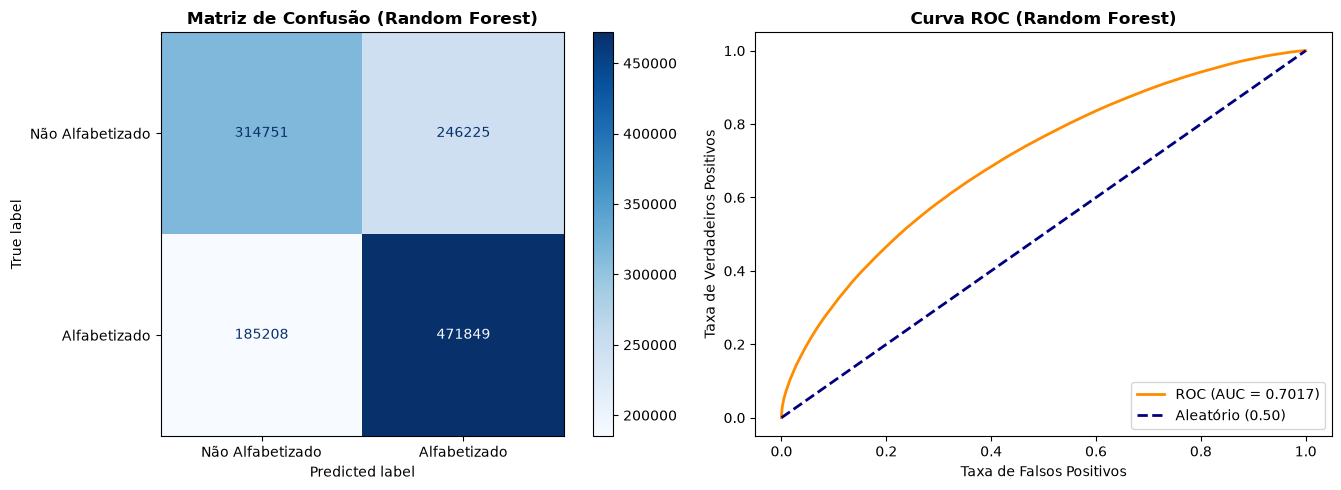

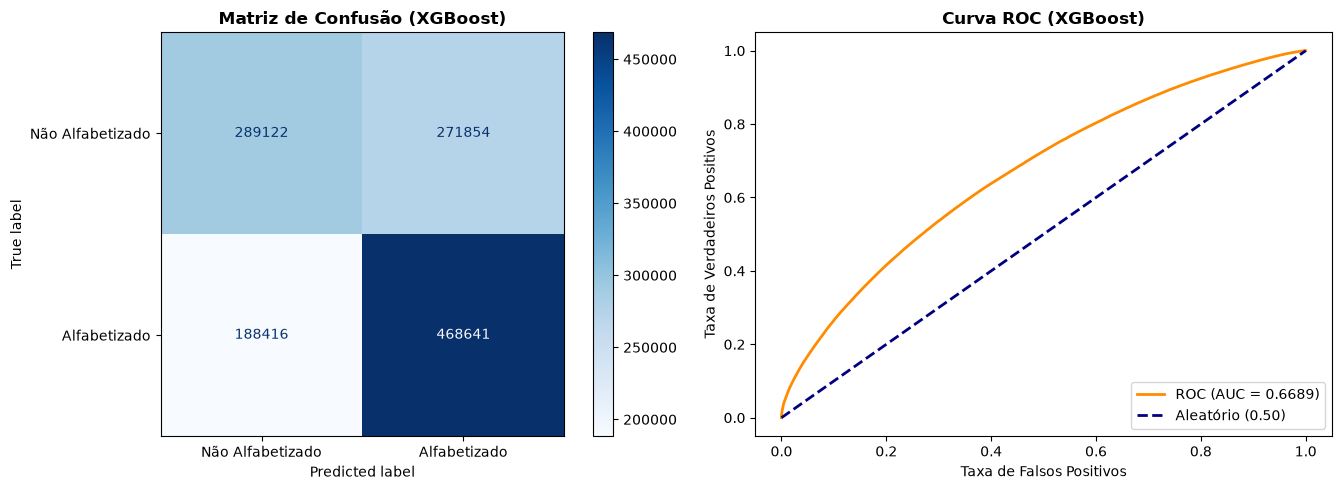

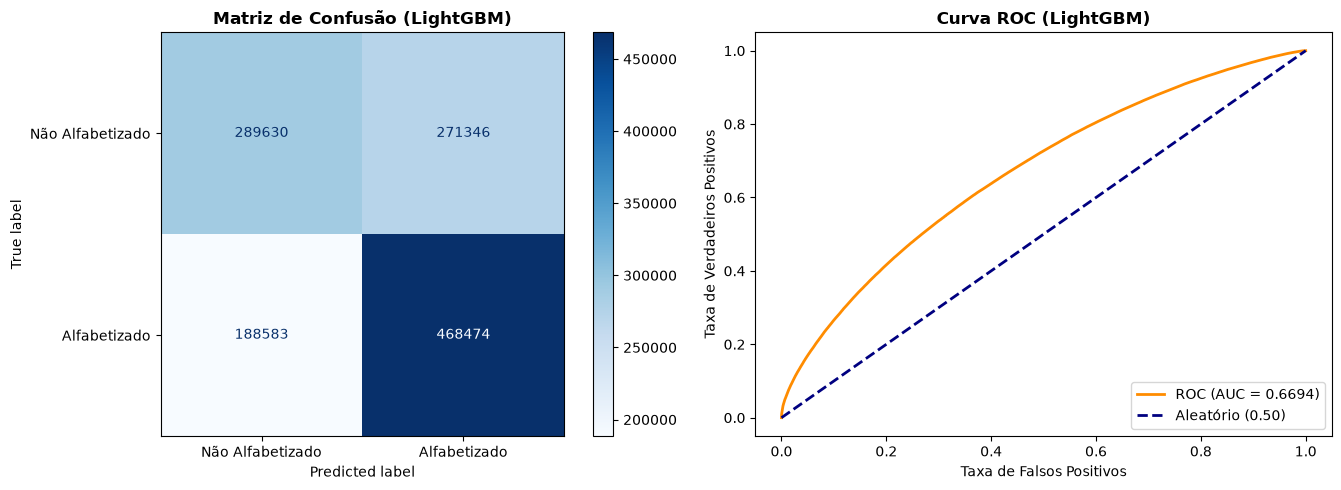

In [ ]:
plot_classificacao(rf, X_test, y_test, model_name="Random Forest")

plot_classificacao(xgb, X_test, y_test, model_name="XGBoost")

plot_classificacao(lgbm, X_test, y_test, model_name="LightGBM")

In [26]:
import joblib
import os

# 1. Garante que a pasta models existe
os.makedirs("models", exist_ok=True)

# 2. Salva o modelo treinado
caminho_local = "models/melhor_modelo_random_forest.joblib"
joblib.dump(rf, caminho_local)

tamanho_mb = os.path.getsize(caminho_local) / (1024 * 1024)
print(f"Modelo Random Forest salvo com sucesso em: {caminho_local} ({tamanho_mb:.2f} MB)")

#SALVAR NO S3 
caminho_s3 = "models/melhor_modelo_random_forest.joblib"

# Faz o upload do arquivo salvo para o bucket
s3.upload_file(caminho_local, BUCKET, caminho_s3)
print(f" Modelo enviado com sucesso para s3://{BUCKET}/{caminho_s3}!")


# import joblib

# # Carrega o modelo treinado instantaneamente (sem precisar treinar de novo)
# modelo_carregado = joblib.load("models/melhor_modelo_random_forest.joblib")

# # Faz previsões com ele:
# novas_previsoes = modelo_carregado.predict(X_test)
# print("Previsões geradas com sucesso!")



Modelo Random Forest salvo com sucesso em: models/melhor_modelo_random_forest.joblib (1059.38 MB)
 Modelo enviado com sucesso para s3://postech-challenge-datascience-003/models/melhor_modelo_random_forest.joblib!


# Ceci

In [36]:
df_modelo              = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="modelo/tabela_modelo_v2")
display(df_modelo.head(10))

Lendo: s3://postech-challenge-datascience-003/gold/modelo/tabela_modelo_v2.parquet
Carregado: 6,090,791 linhas x 15 colunas


,NU_ANO_AVALIACAO,CO_UF,CO_MUNICIPIO,ID_ESCOLA,IN_ALFABETIZADO,TP_DEPENDENCIA,IN_PRESENCA_LP,IN_PREENCHIMENTO_LP,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,VL_MEDIA_LP_TOTAL_MUNICIPIO,PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO,VL_MEDIA_LP_TOTAL_UF,PC_ALUNO_ALFABETIZADO_TOTAL_UF
0,2023,11,1100205.0,60000001.0,0,3.0,0,0,2916.0,1524.801152,89.593066,760.4047,64.47,759.4357,64.6
1,2023,11,1100205.0,60000001.0,0,3.0,1,1,2916.0,1524.801152,89.593066,760.4047,64.47,759.4357,64.6
2,2023,11,1100205.0,60000001.0,0,3.0,0,0,2916.0,1524.801152,89.593066,760.4047,64.47,759.4357,64.6
3,2023,11,1100205.0,60000001.0,1,3.0,1,1,2916.0,1524.801152,89.593066,760.4047,64.47,759.4357,64.6
4,2023,11,1100205.0,60000001.0,0,3.0,0,0,2916.0,1524.801152,89.593066,760.4047,64.47,759.4357,64.6
5,2023,11,1100205.0,60000001.0,1,3.0,1,1,2916.0,1524.801152,89.593066,760.4047,64.47,759.4357,64.6
6,2023,11,1100205.0,60000001.0,1,3.0,1,1,2916.0,1524.801152,89.593066,760.4047,64.47,759.4357,64.6
7,2023,11,1100205.0,60000001.0,0,3.0,0,0,2916.0,1524.801152,89.593066,760.4047,64.47,759.4357,64.6
8,2023,11,1100205.0,60000001.0,1,3.0,1,1,2916.0,1524.801152,89.593066,760.4047,64.47,759.4357,64.6
9,2023,11,1100205.0,60000001.0,1,3.0,1,1,2916.0,1524.801152,89.593066,760.4047,64.47,759.4357,64.6


In [37]:
df_modelo.columns.tolist()

['NU_ANO_AVALIACAO',
 'CO_UF',
 'CO_MUNICIPIO',
 'ID_ESCOLA',
 'IN_ALFABETIZADO',
 'TP_DEPENDENCIA',
 'IN_PRESENCA_LP',
 'IN_PREENCHIMENTO_LP',
 'RENDIMENTO_MEDIO_MENSAL_REAIS',
 'RENDA_PERCAPITA_SBENEF_MEDIO',
 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT',
 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
 'VL_MEDIA_LP_TOTAL_UF',
 'PC_ALUNO_ALFABETIZADO_TOTAL_UF']

In [39]:
df_train = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2023
].copy()

df_val = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2024
].copy()

df_test = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2025
].copy()

In [40]:
TARGET = "IN_ALFABETIZADO"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

In [41]:
print("Treino 2023:", df_train.shape)
print("Validação 2024:", df_val.shape)
print("Teste 2025:", df_test.shape)

Treino 2023: (1747439, 15)
Validação 2024: (2120560, 15)
Teste 2025: (2222792, 15)


In [42]:
print(df_train["NU_ANO_AVALIACAO"].unique())
print(df_val["NU_ANO_AVALIACAO"].unique())
print(df_test["NU_ANO_AVALIACAO"].unique())

[2023]
[2024]
[2025]


In [43]:
TARGET = "IN_ALFABETIZADO"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

In [44]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1747439, 14)
y_train: (1747439,)
X_val: (2120560, 14)
y_val: (2120560,)
X_test: (2222792, 14)
y_test: (2222792,)


In [45]:
X_train.columns.tolist()

['NU_ANO_AVALIACAO',
 'CO_UF',
 'CO_MUNICIPIO',
 'ID_ESCOLA',
 'TP_DEPENDENCIA',
 'IN_PRESENCA_LP',
 'IN_PREENCHIMENTO_LP',
 'RENDIMENTO_MEDIO_MENSAL_REAIS',
 'RENDA_PERCAPITA_SBENEF_MEDIO',
 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT',
 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
 'VL_MEDIA_LP_TOTAL_UF',
 'PC_ALUNO_ALFABETIZADO_TOTAL_UF']

In [46]:
# Taxa de alfabetização por município e ano
hist_municipio = (
    df_modelo
    .groupby(["CO_MUNICIPIO", "NU_ANO_AVALIACAO"])["IN_ALFABETIZADO"]
    .mean()
    .reset_index()
    .rename(columns={
        "IN_ALFABETIZADO": "TAXA_ALF_MUNICIPIO"
    })
)

hist_municipio.head()

,CO_MUNICIPIO,NU_ANO_AVALIACAO,TAXA_ALF_MUNICIPIO
0,1100015.0,2023,0.602362
1,1100015.0,2024,0.611111
2,1100015.0,2025,0.715254
3,1100023.0,2023,0.561352
4,1100023.0,2024,0.584513


In [47]:
hist_municipio["TAXA_ALF_MUNICIPIO_HIST"] = (
    hist_municipio
    .groupby("CO_MUNICIPIO")["TAXA_ALF_MUNICIPIO"]
    .shift(1)
)

hist_municipio.head()

,CO_MUNICIPIO,NU_ANO_AVALIACAO,TAXA_ALF_MUNICIPIO,TAXA_ALF_MUNICIPIO_HIST
0,1100015.0,2023,0.602362,NaN
1,1100015.0,2024,0.611111,0.602362
2,1100015.0,2025,0.715254,0.611111
3,1100023.0,2023,0.561352,NaN
4,1100023.0,2024,0.584513,0.561352


In [48]:
# Taxa de alfabetização por UF e ano
hist_uf = (
    df_modelo
    .groupby(["CO_UF", "NU_ANO_AVALIACAO"])["IN_ALFABETIZADO"]
    .mean()
    .reset_index()
    .rename(columns={
        "IN_ALFABETIZADO": "TAXA_ALF_UF"
    })
)

hist_uf["TAXA_ALF_UF_HIST"] = (
    hist_uf
    .groupby("CO_UF")["TAXA_ALF_UF"]
    .shift(1)
)

hist_uf.head()

,CO_UF,NU_ANO_AVALIACAO,TAXA_ALF_UF,TAXA_ALF_UF_HIST
0,11,2023,0.574845,NaN
1,11,2024,0.556653,0.574845
2,11,2025,0.603251,0.556653
3,12,2024,0.419676,NaN
4,12,2025,0.561808,0.419676


In [49]:
hist_municipio.head(10)

,CO_MUNICIPIO,NU_ANO_AVALIACAO,TAXA_ALF_MUNICIPIO,TAXA_ALF_MUNICIPIO_HIST
0,1100015.0,2023,0.602362,NaN
1,1100015.0,2024,0.611111,0.602362
2,1100015.0,2025,0.715254,0.611111
3,1100023.0,2023,0.561352,NaN
4,1100023.0,2024,0.584513,0.561352
5,1100023.0,2025,0.558435,0.584513
6,1100031.0,2023,0.642857,NaN
7,1100031.0,2024,0.703704,0.642857
8,1100031.0,2025,0.828125,0.703704
9,1100049.0,2023,0.542497,NaN


In [50]:
hist_uf.head(10)

,CO_UF,NU_ANO_AVALIACAO,TAXA_ALF_UF,TAXA_ALF_UF_HIST
0,11,2023,0.574845,NaN
1,11,2024,0.556653,0.574845
2,11,2025,0.603251,0.556653
3,12,2024,0.419676,NaN
4,12,2025,0.561808,0.419676
5,13,2023,0.405709,NaN
6,13,2024,0.396499,0.405709
7,13,2025,0.496632,0.396499
8,14,2025,0.467571,NaN
9,15,2023,0.396496,NaN


In [51]:
df_modelo = df_modelo.merge(
    hist_municipio[
        ["CO_MUNICIPIO", "NU_ANO_AVALIACAO", "TAXA_ALF_MUNICIPIO_HIST"]
    ],
    on=["CO_MUNICIPIO", "NU_ANO_AVALIACAO"],
    how="left"
)

df_modelo = df_modelo.merge(
    hist_uf[
        ["CO_UF", "NU_ANO_AVALIACAO", "TAXA_ALF_UF_HIST"]
    ],
    on=["CO_UF", "NU_ANO_AVALIACAO"],
    how="left"
)

In [52]:
print(df_modelo.shape)

df_modelo[
    [
        "CO_MUNICIPIO",
        "NU_ANO_AVALIACAO",
        "TAXA_ALF_MUNICIPIO_HIST",
        "TAXA_ALF_UF_HIST"
    ]
].head(20)

(6090791, 17)


,CO_MUNICIPIO,NU_ANO_AVALIACAO,TAXA_ALF_MUNICIPIO_HIST,TAXA_ALF_UF_HIST
0,1100205.0,2023,NaN,NaN
1,1100205.0,2023,NaN,NaN
2,1100205.0,2023,NaN,NaN
3,1100205.0,2023,NaN,NaN
4,1100205.0,2023,NaN,NaN
5,1100205.0,2023,NaN,NaN
6,1100205.0,2023,NaN,NaN
7,1100205.0,2023,NaN,NaN
8,1100205.0,2023,NaN,NaN
9,1100205.0,2023,NaN,NaN


In [53]:
df_modelo[
    df_modelo["NU_ANO_AVALIACAO"].isin([2024, 2025])
][
    [
        "CO_MUNICIPIO",
        "NU_ANO_AVALIACAO",
        "TAXA_ALF_MUNICIPIO_HIST",
        "TAXA_ALF_UF_HIST"
    ]
].head(20)

,CO_MUNICIPIO,NU_ANO_AVALIACAO,TAXA_ALF_MUNICIPIO_HIST,TAXA_ALF_UF_HIST
1747439,1100015.0,2024,0.602362,0.574845
1747440,1100015.0,2024,0.602362,0.574845
1747441,1100015.0,2024,0.602362,0.574845
1747442,1100015.0,2024,0.602362,0.574845
1747443,1100015.0,2024,0.602362,0.574845
1747444,1100015.0,2024,0.602362,0.574845
1747445,1100015.0,2024,0.602362,0.574845
1747446,1100015.0,2024,0.602362,0.574845
1747447,1100015.0,2024,0.602362,0.574845
1747448,1100015.0,2024,0.602362,0.574845


In [54]:
df_modelo.groupby("NU_ANO_AVALIACAO")[
    ["TAXA_ALF_MUNICIPIO_HIST", "TAXA_ALF_UF_HIST"]
].apply(lambda x: x.notna().mean())

,TAXA_ALF_MUNICIPIO_HIST,TAXA_ALF_UF_HIST
NU_ANO_AVALIACAO,,
2023,0.000000,0.000000
2024,0.771550,0.771697
2025,0.994508,0.994895


In [55]:
df_modelo.columns.tolist()

['NU_ANO_AVALIACAO',
 'CO_UF',
 'CO_MUNICIPIO',
 'ID_ESCOLA',
 'IN_ALFABETIZADO',
 'TP_DEPENDENCIA',
 'IN_PRESENCA_LP',
 'IN_PREENCHIMENTO_LP',
 'RENDIMENTO_MEDIO_MENSAL_REAIS',
 'RENDA_PERCAPITA_SBENEF_MEDIO',
 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT',
 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
 'VL_MEDIA_LP_TOTAL_UF',
 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
 'TAXA_ALF_MUNICIPIO_HIST',
 'TAXA_ALF_UF_HIST']

In [56]:
#média de LP por município e ano
hist_media_lp_municipio = (
    df_modelo
    .groupby(["CO_MUNICIPIO", "NU_ANO_AVALIACAO"])["VL_MEDIA_LP_TOTAL_MUNICIPIO"]
    .first()
    .reset_index()
    .rename(columns={
        "VL_MEDIA_LP_TOTAL_MUNICIPIO": "MEDIA_LP_MUNICIPIO"
    })
)

hist_media_lp_municipio["MEDIA_LP_MUNICIPIO_HIST"] = (
    hist_media_lp_municipio
    .groupby("CO_MUNICIPIO")["MEDIA_LP_MUNICIPIO"]
    .shift(1)
)

In [57]:
hist_media_lp_municipio.head(10)

,CO_MUNICIPIO,NU_ANO_AVALIACAO,MEDIA_LP_MUNICIPIO,MEDIA_LP_MUNICIPIO_HIST
0,1100015.0,2023,758.3304,NaN
1,1100015.0,2024,752.5000,758.3304
2,1100015.0,2025,763.2938,752.5000
3,1100023.0,2023,757.0999,NaN
4,1100023.0,2024,748.1600,757.0999
5,1100023.0,2025,765.1730,748.1600
6,1100031.0,2023,767.8763,NaN
7,1100031.0,2024,759.6600,767.8763
8,1100031.0,2025,768.9794,759.6600
9,1100049.0,2023,757.0954,NaN


In [58]:
df_modelo = df_modelo.merge(
    hist_media_lp_municipio[
        ["CO_MUNICIPIO", "NU_ANO_AVALIACAO", "MEDIA_LP_MUNICIPIO_HIST"]
    ],
    on=["CO_MUNICIPIO", "NU_ANO_AVALIACAO"],
    how="left"
)

In [59]:
df_modelo[
    [
        "CO_MUNICIPIO",
        "NU_ANO_AVALIACAO",
        "MEDIA_LP_MUNICIPIO_HIST"
    ]
].head(20)

,CO_MUNICIPIO,NU_ANO_AVALIACAO,MEDIA_LP_MUNICIPIO_HIST
0,1100205.0,2023,NaN
1,1100205.0,2023,NaN
2,1100205.0,2023,NaN
3,1100205.0,2023,NaN
4,1100205.0,2023,NaN
5,1100205.0,2023,NaN
6,1100205.0,2023,NaN
7,1100205.0,2023,NaN
8,1100205.0,2023,NaN
9,1100205.0,2023,NaN


In [60]:
df_modelo[
    df_modelo["NU_ANO_AVALIACAO"].isin([2024, 2025])
][
    [
        "CO_MUNICIPIO",
        "NU_ANO_AVALIACAO",
        "MEDIA_LP_MUNICIPIO_HIST"
    ]
].head(20)

,CO_MUNICIPIO,NU_ANO_AVALIACAO,MEDIA_LP_MUNICIPIO_HIST
1747439,1100015.0,2024,758.3304
1747440,1100015.0,2024,758.3304
1747441,1100015.0,2024,758.3304
1747442,1100015.0,2024,758.3304
1747443,1100015.0,2024,758.3304
1747444,1100015.0,2024,758.3304
1747445,1100015.0,2024,758.3304
1747446,1100015.0,2024,758.3304
1747447,1100015.0,2024,758.3304
1747448,1100015.0,2024,758.3304


In [61]:
hist_media_lp_uf = (
    df_modelo
    .groupby(["CO_UF", "NU_ANO_AVALIACAO"])["VL_MEDIA_LP_TOTAL_UF"]
    .first()
    .reset_index()
    .rename(columns={
        "VL_MEDIA_LP_TOTAL_UF": "MEDIA_LP_UF"
    })
)

hist_media_lp_uf["MEDIA_LP_UF_HIST"] = (
    hist_media_lp_uf
    .groupby("CO_UF")["MEDIA_LP_UF"]
    .shift(1)
)

In [62]:
hist_media_lp_uf.head(10)

,CO_UF,NU_ANO_AVALIACAO,MEDIA_LP_UF,MEDIA_LP_UF_HIST
0,11,2023,759.4357,NaN
1,11,2024,745.5200,759.4357
2,11,2025,761.7828,745.5200
3,12,2024,739.1500,NaN
4,12,2025,752.7504,739.1500
5,13,2023,736.4687,NaN
6,13,2024,734.1200,736.4687
7,13,2025,741.9726,734.1200
8,14,2025,744.6037,NaN
9,15,2023,733.2877,NaN


In [63]:
df_modelo = df_modelo.merge(
    hist_media_lp_uf[
        ["CO_UF", "NU_ANO_AVALIACAO", "MEDIA_LP_UF_HIST"]
    ],
    on=["CO_UF", "NU_ANO_AVALIACAO"],
    how="left"
)

In [64]:
df_modelo[
    [
        "CO_UF",
        "NU_ANO_AVALIACAO",
        "MEDIA_LP_UF_HIST"
    ]
].head(20)

,CO_UF,NU_ANO_AVALIACAO,MEDIA_LP_UF_HIST
0,11,2023,NaN
1,11,2023,NaN
2,11,2023,NaN
3,11,2023,NaN
4,11,2023,NaN
5,11,2023,NaN
6,11,2023,NaN
7,11,2023,NaN
8,11,2023,NaN
9,11,2023,NaN


In [65]:
df_modelo[
    df_modelo["NU_ANO_AVALIACAO"].isin([2024, 2025])
][
    [
        "CO_UF",
        "NU_ANO_AVALIACAO",
        "MEDIA_LP_UF_HIST"
    ]
].head(20)

,CO_UF,NU_ANO_AVALIACAO,MEDIA_LP_UF_HIST
1747439,11,2024,759.4357
1747440,11,2024,759.4357
1747441,11,2024,759.4357
1747442,11,2024,759.4357
1747443,11,2024,759.4357
1747444,11,2024,759.4357
1747445,11,2024,759.4357
1747446,11,2024,759.4357
1747447,11,2024,759.4357
1747448,11,2024,759.4357


In [67]:
#absenteísmo
hist_freq_uf = (
    df_modelo
    .groupby(["CO_UF", "NU_ANO_AVALIACAO"])["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"]
    .first()
    .reset_index()
    .rename(columns={
        "UF_TAXA_FREQ_LIQUIDA_FUND_PCT": "FREQ_UF"
    })
)

hist_freq_uf["FREQ_UF_HIST"] = (
    hist_freq_uf
    .groupby("CO_UF")["FREQ_UF"]
    .shift(1)
)

In [68]:
hist_freq_uf.head(10)

,CO_UF,NU_ANO_AVALIACAO,FREQ_UF,FREQ_UF_HIST
0,11,2023,89.593066,NaN
1,11,2024,89.593066,89.593066
2,11,2025,89.593066,89.593066
3,12,2024,88.407203,NaN
4,12,2025,88.407203,88.407203
5,13,2023,92.050449,NaN
6,13,2024,92.050449,92.050449
7,13,2025,92.050449,92.050449
8,14,2025,86.084759,NaN
9,15,2023,92.134734,NaN


In [69]:
df_modelo = df_modelo.merge(
    hist_freq_uf[
        ["CO_UF", "NU_ANO_AVALIACAO", "FREQ_UF_HIST"]
    ],
    on=["CO_UF", "NU_ANO_AVALIACAO"],
    how="left"
)

In [71]:
df_modelo[
    df_modelo["NU_ANO_AVALIACAO"].isin([2024, 2025])
][
    [
        "CO_UF",
        "NU_ANO_AVALIACAO",
        "FREQ_UF_HIST"
    ]
].head(20)

,CO_UF,NU_ANO_AVALIACAO,FREQ_UF_HIST
1747439,11,2024,89.593066
1747440,11,2024,89.593066
1747441,11,2024,89.593066
1747442,11,2024,89.593066
1747443,11,2024,89.593066
1747444,11,2024,89.593066
1747445,11,2024,89.593066
1747446,11,2024,89.593066
1747447,11,2024,89.593066
1747448,11,2024,89.593066


## METAS

In [74]:
df_meta              = carregar_parquet_s3(s3, BUCKET, camada="bronze", nome_tabela="ano=2023/dados/RESULTADOS_METAS"  )
display(df_meta.head(50))

Lendo: s3://postech-challenge-datascience-003/bronze/ano=2023/dados/RESULTADOS_METAS.parquet
Carregado: 28 linhas x 16 colunas


,ANO,CD_UF,SIGLA_UF,NOME_UF,REDE,SAEB_2019,SAEB_2021,PC_ALUNO_ALFABETIZADO,META_FINAL_2024,META_FINAL_2025,META_FINAL_2026,META_FINAL_2027,META_FINAL_2028,META_FINAL_2029,META_FINAL_2030,PC_AVALIADOS_LP
0,2023,NaN,NaN,Brasil,PÚBLICA,54.70,35.77,55.89811,59.897807,63.769871,67.471106,70.966377,74.229525,77.243526,> 80,86.00
1,2023,12.0,AC,Acre,PÚBLICA,52.87,20.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN
2,2023,27.0,AL,Alagoas,PÚBLICA,39.01,30.04,43.88000,49.700000,55.500000,61.100000,66.500000,71.500000,76.000000,> 80,92.36
3,2023,13.0,AM,Amazonas,PÚBLICA,43.83,28.76,52.20000,56.800000,61.300000,65.600000,69.600000,73.400000,76.900000,> 80,76.14
4,2023,16.0,AP,Amapá,PÚBLICA,24.77,18.77,41.56000,47.600000,53.800000,59.900000,65.600000,70.900000,75.800000,> 80,89.68
5,2023,29.0,BA,Bahia,PÚBLICA,41.36,24.49,36.80000,43.400000,50.200000,57.100000,63.600000,69.800000,75.200000,> 80,84.53
6,2023,23.0,CE,Ceará,PÚBLICA,73.48,44.93,84.50000,NaN,NaN,NaN,NaN,NaN,NaN,>80,95.22
7,2023,53.0,DF,Distrito Federal,PÚBLICA,63.36,39.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN
8,2023,32.0,ES,Espírito Santo,PÚBLICA,62.45,46.10,67.93000,69.900000,71.800000,73.600000,75.300000,76.900000,78.500000,> 80,88.40
9,2023,52.0,GO,Goiás,PÚBLICA,63.00,38.94,66.70000,68.900000,71.000000,73.000000,74.900000,76.700000,78.400000,> 80,87.03


In [75]:
df_meta.columns.tolist()

['ANO',
 'CD_UF',
 'SIGLA_UF',
 'NOME_UF',
 'REDE',
 'SAEB_2019',
 'SAEB_2021',
 'PC_ALUNO_ALFABETIZADO',
 'META_FINAL_2024',
 'META_FINAL_2025',
 'META_FINAL_2026',
 'META_FINAL_2027',
 'META_FINAL_2028',
 'META_FINAL_2029',
 'META_FINAL_2030',
 'PC_AVALIADOS_LP']

In [78]:
df_meta[
    [
        "ANO",
        "CD_UF",
        "SAEB_2019",
        "SAEB_2021",
        "PC_ALUNO_ALFABETIZADO",
        "META_FINAL_2024",
        "META_FINAL_2025",
        "META_FINAL_2026"
    ]
].head(20)

,ANO,CD_UF,SAEB_2019,SAEB_2021,PC_ALUNO_ALFABETIZADO,META_FINAL_2024,META_FINAL_2025,META_FINAL_2026
0,2023,NaN,54.70,35.77,55.89811,59.897807,63.769871,67.471106
1,2023,12.0,52.87,20.05,NaN,NaN,NaN,NaN
2,2023,27.0,39.01,30.04,43.88000,49.700000,55.500000,61.100000
3,2023,13.0,43.83,28.76,52.20000,56.800000,61.300000,65.600000
4,2023,16.0,24.77,18.77,41.56000,47.600000,53.800000,59.900000
5,2023,29.0,41.36,24.49,36.80000,43.400000,50.200000,57.100000
6,2023,23.0,73.48,44.93,84.50000,NaN,NaN,NaN
7,2023,53.0,63.36,39.85,NaN,NaN,NaN,NaN
8,2023,32.0,62.45,46.10,67.93000,69.900000,71.800000,73.600000
9,2023,52.0,63.00,38.94,66.70000,68.900000,71.000000,73.000000


In [79]:
df_meta[["ANO", "CD_UF"]].drop_duplicates().sort_values(
    ["CD_UF", "ANO"]
).head(30)

,ANO,CD_UF
21,2023,11.0
1,2023,12.0
3,2023,13.0
22,2023,14.0
14,2023,15.0
4,2023,16.0
27,2023,17.0
10,2023,21.0
17,2023,22.0
6,2023,23.0


In [81]:
meta_modelo = df_meta[
    [
        "CD_UF",
        "SAEB_2019",
        "SAEB_2021",
        "META_FINAL_2024",
        "META_FINAL_2025",
        "META_FINAL_2026",
        "META_FINAL_2027",
        "META_FINAL_2028",
        "META_FINAL_2029",
        "META_FINAL_2030"
    ]
].dropna(subset=["CD_UF"]).drop_duplicates("CD_UF")

In [82]:
meta_modelo.shape

(27, 10)

In [83]:
meta_modelo.head()

,CD_UF,SAEB_2019,SAEB_2021,META_FINAL_2024,META_FINAL_2025,META_FINAL_2026,META_FINAL_2027,META_FINAL_2028,META_FINAL_2029,META_FINAL_2030
1,12.0,52.87,20.05,NaN,NaN,NaN,NaN,NaN,NaN,-
2,27.0,39.01,30.04,49.7,55.5,61.1,66.5,71.5,76.0,> 80
3,13.0,43.83,28.76,56.8,61.3,65.6,69.6,73.4,76.9,> 80
4,16.0,24.77,18.77,47.6,53.8,59.9,65.6,70.9,75.8,> 80
5,29.0,41.36,24.49,43.4,50.2,57.1,63.6,69.8,75.2,> 80


In [84]:
#transformando a meta em numero
df_meta["META_FINAL_2030"] = (
    df_meta["META_FINAL_2030"]
    .astype(str)
    .str.replace(">", "", regex=False)
    .str.strip()
)

df_meta["META_FINAL_2030"] = pd.to_numeric(
    df_meta["META_FINAL_2030"],
    errors="coerce"
)

In [85]:
df_meta["META_FINAL_2030"].unique()

array([80., nan])

In [86]:
meta_modelo = df_meta[
    [
        "CD_UF",
        "SAEB_2019",
        "SAEB_2021",
        "META_FINAL_2024",
        "META_FINAL_2025",
        "META_FINAL_2026",
        "META_FINAL_2027",
        "META_FINAL_2028",
        "META_FINAL_2029",
        "META_FINAL_2030"
    ]
].dropna(subset=["CD_UF"]).drop_duplicates("CD_UF")

In [87]:
meta_modelo.head()

,CD_UF,SAEB_2019,SAEB_2021,META_FINAL_2024,META_FINAL_2025,META_FINAL_2026,META_FINAL_2027,META_FINAL_2028,META_FINAL_2029,META_FINAL_2030
1,12.0,52.87,20.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,27.0,39.01,30.04,49.7,55.5,61.1,66.5,71.5,76.0,80.0
3,13.0,43.83,28.76,56.8,61.3,65.6,69.6,73.4,76.9,80.0
4,16.0,24.77,18.77,47.6,53.8,59.9,65.6,70.9,75.8,80.0
5,29.0,41.36,24.49,43.4,50.2,57.1,63.6,69.8,75.2,80.0


In [88]:
meta_modelo.dtypes

CD_UF              float64
SAEB_2019          float64
SAEB_2021          float64
META_FINAL_2024    float64
META_FINAL_2025    float64
META_FINAL_2026    float64
META_FINAL_2027    float64
META_FINAL_2028    float64
META_FINAL_2029    float64
META_FINAL_2030    float64
dtype: object

In [89]:
df_modelo["CO_UF"] = df_modelo["CO_UF"].astype("float64")

df_modelo = df_modelo.merge(
    meta_modelo,
    left_on="CO_UF",
    right_on="CD_UF",
    how="left"
)

In [90]:
df_modelo[
    [
        "CO_UF",
        "SAEB_2019",
        "SAEB_2021",
        "META_FINAL_2024",
        "META_FINAL_2025",
        "META_FINAL_2030"
    ]
].head(20)

,CO_UF,SAEB_2019,SAEB_2021,META_FINAL_2024,META_FINAL_2025,META_FINAL_2030
0,11.0,46.18,25.22,67.1,69.5,80.0
1,11.0,46.18,25.22,67.1,69.5,80.0
2,11.0,46.18,25.22,67.1,69.5,80.0
3,11.0,46.18,25.22,67.1,69.5,80.0
4,11.0,46.18,25.22,67.1,69.5,80.0
5,11.0,46.18,25.22,67.1,69.5,80.0
6,11.0,46.18,25.22,67.1,69.5,80.0
7,11.0,46.18,25.22,67.1,69.5,80.0
8,11.0,46.18,25.22,67.1,69.5,80.0
9,11.0,46.18,25.22,67.1,69.5,80.0


In [92]:
df_modelo.columns.tolist()

['NU_ANO_AVALIACAO',
 'CO_UF',
 'CO_MUNICIPIO',
 'ID_ESCOLA',
 'IN_ALFABETIZADO',
 'TP_DEPENDENCIA',
 'IN_PRESENCA_LP',
 'IN_PREENCHIMENTO_LP',
 'RENDIMENTO_MEDIO_MENSAL_REAIS',
 'RENDA_PERCAPITA_SBENEF_MEDIO',
 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT',
 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
 'VL_MEDIA_LP_TOTAL_UF',
 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
 'TAXA_ALF_MUNICIPIO_HIST',
 'TAXA_ALF_UF_HIST',
 'MEDIA_LP_MUNICIPIO_HIST',
 'MEDIA_LP_UF_HIST',
 'FREQ_UF_HIST',
 'CD_UF',
 'SAEB_2019',
 'SAEB_2021',
 'META_FINAL_2024',
 'META_FINAL_2025',
 'META_FINAL_2026',
 'META_FINAL_2027',
 'META_FINAL_2028',
 'META_FINAL_2029',
 'META_FINAL_2030']

In [91]:
X_train
X_val
X_test
y_train
y_val
y_test

3867999    1
3868000    0
3868001    0
3868002    1
3868003    1
          ..
6090786    1
6090787    1
6090788    0
6090789    0
6090790    0
Name: IN_ALFABETIZADO, Length: 2222792, dtype: int64

In [96]:
FEATURES = [
    "CO_UF",
    "CO_MUNICIPIO",
    "TP_DEPENDENCIA",

    "RENDIMENTO_MEDIO_MENSAL_REAIS",
    "RENDA_PERCAPITA_SBENEF_MEDIO",
    "UF_TAXA_FREQ_LIQUIDA_FUND_PCT",

    # histórico
    "TAXA_ALF_MUNICIPIO_HIST",
    "TAXA_ALF_UF_HIST",
    "MEDIA_LP_MUNICIPIO_HIST",
    "MEDIA_LP_UF_HIST",
    "FREQ_UF_HIST",

    # histórico SAEB
    "SAEB_2019",
    "SAEB_2021",

    # meta do ano que estamos prevendo
    "META_FINAL_2025"
]

In [97]:
#Excluir target e leakege 
COLUNAS_EXCLUIR = [
    "IN_ALFABETIZADO",  # target

    "ID_ESCOLA",        # identificador, não característica

    # resultado do próprio ano → leakage
    "VL_MEDIA_LP_TOTAL_MUNICIPIO",
    "PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO",
    "VL_MEDIA_LP_TOTAL_UF",
    "PC_ALUNO_ALFABETIZADO_TOTAL_UF",

    # duplicada de CO_UF
    "CD_UF",

    # ano já está representado pela separação temporal
    "NU_ANO_AVALIACAO"
]

In [99]:
df_train = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2023
].copy()

df_val = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2024
].copy()

df_test = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2025
].copy()

In [100]:
X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET]

X_val = df_val[FEATURES].copy()
y_val = df_val[TARGET]

X_test = df_test[FEATURES].copy()
y_test = df_test[TARGET]

In [101]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (1747439, 14)
X_val: (2120560, 14)
X_test: (2222792, 14)


In [102]:
X_train.isna().sum().sort_values(ascending=False)

TAXA_ALF_MUNICIPIO_HIST          1747439
TAXA_ALF_UF_HIST                 1747439
MEDIA_LP_MUNICIPIO_HIST          1747439
MEDIA_LP_UF_HIST                 1747439
FREQ_UF_HIST                     1747439
META_FINAL_2025                   100349
CO_UF                                  0
CO_MUNICIPIO                           0
TP_DEPENDENCIA                         0
RENDIMENTO_MEDIO_MENSAL_REAIS          0
RENDA_PERCAPITA_SBENEF_MEDIO           0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT          0
SAEB_2019                              0
SAEB_2021                              0
dtype: int64

In [103]:
X_val.isna().sum().sort_values(ascending=False)

MEDIA_LP_MUNICIPIO_HIST          484494
TAXA_ALF_MUNICIPIO_HIST          484442
TAXA_ALF_UF_HIST                 484130
MEDIA_LP_UF_HIST                 484130
FREQ_UF_HIST                     484130
META_FINAL_2025                  130194
CO_UF                                 0
CO_MUNICIPIO                          0
TP_DEPENDENCIA                        0
RENDIMENTO_MEDIO_MENSAL_REAIS         0
RENDA_PERCAPITA_SBENEF_MEDIO          0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT         0
SAEB_2019                             0
SAEB_2021                             0
dtype: int64

In [104]:
X_test.isna().sum().sort_values(ascending=False)

META_FINAL_2025                  146157
MEDIA_LP_UF_HIST                  39350
MEDIA_LP_MUNICIPIO_HIST           15679
TAXA_ALF_MUNICIPIO_HIST           12207
TAXA_ALF_UF_HIST                  11348
FREQ_UF_HIST                      11348
CO_MUNICIPIO                        628
TP_DEPENDENCIA                      628
RENDIMENTO_MEDIO_MENSAL_REAIS       628
UF_TAXA_FREQ_LIQUIDA_FUND_PCT       628
CO_UF                                 0
RENDA_PERCAPITA_SBENEF_MEDIO          0
SAEB_2019                             0
SAEB_2021                             0
dtype: int64

### Tratando nulos

In [105]:
print("2024:")
print(X_val.isna().sum().sort_values(ascending=False))

print("\n2025:")
print(X_test.isna().sum().sort_values(ascending=False))

2024:
MEDIA_LP_MUNICIPIO_HIST          484494
TAXA_ALF_MUNICIPIO_HIST          484442
TAXA_ALF_UF_HIST                 484130
MEDIA_LP_UF_HIST                 484130
FREQ_UF_HIST                     484130
META_FINAL_2025                  130194
CO_UF                                 0
CO_MUNICIPIO                          0
TP_DEPENDENCIA                        0
RENDIMENTO_MEDIO_MENSAL_REAIS         0
RENDA_PERCAPITA_SBENEF_MEDIO          0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT         0
SAEB_2019                             0
SAEB_2021                             0
dtype: int64

2025:
META_FINAL_2025                  146157
MEDIA_LP_UF_HIST                  39350
MEDIA_LP_MUNICIPIO_HIST           15679
TAXA_ALF_MUNICIPIO_HIST           12207
TAXA_ALF_UF_HIST                  11348
FREQ_UF_HIST                      11348
CO_MUNICIPIO                        628
TP_DEPENDENCIA                      628
RENDIMENTO_MEDIO_MENSAL_REAIS       628
UF_TAXA_FREQ_LIQUIDA_FUND_PCT       628
CO_UF         

In [106]:
df_test[
    df_test["META_FINAL_2025"].isna()
]["CO_UF"].value_counts().sort_index()

CO_UF
12.0    12741
14.0    11348
23.0    94066
53.0    28002
Name: count, dtype: int64

In [107]:
df_test[
    df_test["META_FINAL_2025"].isna()
][["CO_UF", "CO_MUNICIPIO"]].drop_duplicates().head(30)

,CO_UF,CO_MUNICIPIO
3894638,12.0,1200054.0
3894788,12.0,1200104.0
3895320,12.0,1200252.0
3895671,12.0,1200708.0
3895925,12.0,1200013.0
3896193,12.0,1200138.0
3896371,12.0,1200179.0
3896571,12.0,1200385.0
3896849,12.0,1200401.0
3902274,12.0,1200450.0


In [108]:
historicos = [
    "TAXA_ALF_MUNICIPIO_HIST",
    "TAXA_ALF_UF_HIST",
    "MEDIA_LP_MUNICIPIO_HIST",
    "MEDIA_LP_UF_HIST",
    "FREQ_UF_HIST"
]

print("2024:", 
      X_val[historicos].notna().all(axis=1).mean())

print("2025:", 
      X_test[historicos].notna().all(axis=1).mean())

2024: 0.7715254461085751
2025: 0.9803485886218773


DADOS 2023
   ↓
gera histórico
   ↓
DADOS 2024 ─────► TREINA MODELO
                       ↓
                 validação interna
                       ↓
DADOS 2025 ─────► TESTE FINAL
                       ↓
              previsão de alfabetização
                       ↓
                compara com META

In [109]:
X_val[historicos].isna().sum().sort_values(ascending=False)

MEDIA_LP_MUNICIPIO_HIST    484494
TAXA_ALF_MUNICIPIO_HIST    484442
TAXA_ALF_UF_HIST           484130
MEDIA_LP_UF_HIST           484130
FREQ_UF_HIST               484130
dtype: int64

In [110]:
X_val[historicos].isna().mean().sort_values(ascending=False)

MEDIA_LP_MUNICIPIO_HIST    0.228475
TAXA_ALF_MUNICIPIO_HIST    0.228450
TAXA_ALF_UF_HIST           0.228303
MEDIA_LP_UF_HIST           0.228303
FREQ_UF_HIST               0.228303
dtype: float64

### Features de histórico e meta são muito importantes para o modelo, então vamos filtrar apenas as linhas que possuem esses dados.

In [111]:
FEATURES = [
    "CO_UF",
    "CO_MUNICIPIO",
    "TP_DEPENDENCIA",
    "RENDIMENTO_MEDIO_MENSAL_REAIS",
    "RENDA_PERCAPITA_SBENEF_MEDIO",
    "UF_TAXA_FREQ_LIQUIDA_FUND_PCT",
    "TAXA_ALF_MUNICIPIO_HIST",
    "TAXA_ALF_UF_HIST",
    "MEDIA_LP_MUNICIPIO_HIST",
    "MEDIA_LP_UF_HIST",
    "FREQ_UF_HIST",
    "SAEB_2019",
    "SAEB_2021"
]

TARGET = "IN_ALFABETIZADO"

X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET]

X_val = df_val[FEATURES].copy()
y_val = df_val[TARGET]

X_test = df_test[FEATURES].copy()
y_test = df_test[TARGET]

## LightGBM

In [114]:
#treino e teste com 2024 e 2025
df_train = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2024
].copy()

df_test = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2025
].copy()

In [116]:
#Features
FEATURES = [
    "CO_UF",
    "CO_MUNICIPIO",
    "TP_DEPENDENCIA",
    "RENDIMENTO_MEDIO_MENSAL_REAIS",
    "RENDA_PERCAPITA_SBENEF_MEDIO",
    "UF_TAXA_FREQ_LIQUIDA_FUND_PCT",
    "TAXA_ALF_MUNICIPIO_HIST",
    "TAXA_ALF_UF_HIST",
    "MEDIA_LP_MUNICIPIO_HIST",
    "MEDIA_LP_UF_HIST",
    "FREQ_UF_HIST",
    "SAEB_2019",
    "SAEB_2021"
]

TARGET = "IN_ALFABETIZADO"

X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET]

X_test = df_test[FEATURES].copy()
y_test = df_test[TARGET]

In [117]:
#transformando as colunas categoricas em tipo Categorical para evitar problemas de categorias diferentes entre treino e teste
CATEGORICAS = [
    "CO_UF",
    "CO_MUNICIPIO",
    "TP_DEPENDENCIA"
]

for col in CATEGORICAS:
    categorias = pd.concat([
        X_train[col],
        X_test[col]
    ]).dropna().unique()

    X_train[col] = pd.Categorical(
        X_train[col],
        categories=categorias
    )

    X_test[col] = pd.Categorical(
        X_test[col],
        categories=categorias
    )

In [118]:
X_train[CATEGORICAS].dtypes

CO_UF             category
CO_MUNICIPIO      category
TP_DEPENDENCIA    category
dtype: object

In [119]:
print("Treino 2024:", X_train.shape)
print("Teste 2025:", X_test.shape)

Treino 2024: (2120560, 13)
Teste 2025: (2222792, 13)


In [120]:
import lightgbm as lgb

print(lgb.__version__)

4.7.0


In [121]:
# Treinamento do LightGBM 
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

modelo_lgb = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

modelo_lgb.fit(
    X_train,
    y_train,
    categorical_feature=CATEGORICAS
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 1107119, number of negative: 1013441
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5339
[LightGBM] [Info] Number of data points in the train set: 2120560, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522088 -> initscore=0.088410
[LightGBM] [Info] Start training from score 0.088410


,learning_rate,0.05
,n_estimators,300
,objective,'binary'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000


In [122]:
y_pred = modelo_lgb.predict(X_test)
y_prob = modelo_lgb.predict_proba(X_test)[:, 1]

In [123]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.6333100396377773

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.52      0.52    919754
           1       0.66      0.66      0.66   1303038

    accuracy                           0.60   2222792
   macro avg       0.59      0.59      0.59   2222792
weighted avg       0.60      0.60      0.60   2222792


Matriz de Confusão:
[[481553 438201]
 [443765 859273]]


o modelo tem algum poder de discriminação, mas ainda está longe de uma separação forte entre alfabetizados e não alfabetizados

In [126]:
importancias = pd.DataFrame({
    "FEATURE": X_train.columns,
    "IMPORTANCIA": modelo_lgb.feature_importances_
}).sort_values(
    "IMPORTANCIA",
    ascending=False
)

importancias

,FEATURE,IMPORTANCIA
1,CO_MUNICIPIO,5894
6,TAXA_ALF_MUNICIPIO_HIST,941
8,MEDIA_LP_MUNICIPIO_HIST,719
0,CO_UF,565
2,TP_DEPENDENCIA,402
3,RENDIMENTO_MEDIO_MENSAL_REAIS,113
5,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,100
7,TAXA_ALF_UF_HIST,65
4,RENDA_PERCAPITA_SBENEF_MEDIO,61
11,SAEB_2019,40


In [127]:
importancias_gain = pd.DataFrame({
    "FEATURE": X_train.columns,
    "IMPORTANCIA": modelo_lgb.booster_.feature_importance(
        importance_type="gain"
    )
}).sort_values(
    "IMPORTANCIA",
    ascending=False
)

importancias_gain

,FEATURE,IMPORTANCIA
6,TAXA_ALF_MUNICIPIO_HIST,1.001678e+06
1,CO_MUNICIPIO,7.050601e+05
0,CO_UF,3.781231e+05
8,MEDIA_LP_MUNICIPIO_HIST,2.170639e+05
2,TP_DEPENDENCIA,3.021470e+04
7,TAXA_ALF_UF_HIST,1.787456e+04
4,RENDA_PERCAPITA_SBENEF_MEDIO,1.669446e+04
10,FREQ_UF_HIST,8.626140e+03
5,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,6.938157e+03
3,RENDIMENTO_MEDIO_MENSAL_REAIS,6.079236e+03


## modelo B: Sem CO_MUNICIPIO

In [128]:
FEATURES_SEM_MUNICIPIO = [
    "CO_UF",
    "TP_DEPENDENCIA",
    "RENDIMENTO_MEDIO_MENSAL_REAIS",
    "RENDA_PERCAPITA_SBENEF_MEDIO",
    "UF_TAXA_FREQ_LIQUIDA_FUND_PCT",
    "TAXA_ALF_MUNICIPIO_HIST",
    "TAXA_ALF_UF_HIST",
    "MEDIA_LP_MUNICIPIO_HIST",
    "MEDIA_LP_UF_HIST",
    "FREQ_UF_HIST",
    "SAEB_2019",
    "SAEB_2021"
]

In [129]:
X_train_b = df_train[FEATURES_SEM_MUNICIPIO].copy()
X_test_b = df_test[FEATURES_SEM_MUNICIPIO].copy()

In [130]:
X_train_b["CO_UF"] = X_train_b["CO_UF"].astype("category")
X_test_b["CO_UF"] = X_test_b["CO_UF"].astype("category")

X_train_b["TP_DEPENDENCIA"] = X_train_b["TP_DEPENDENCIA"].astype("category")
X_test_b["TP_DEPENDENCIA"] = X_test_b["TP_DEPENDENCIA"].astype("category")

In [131]:
modelo_lgb_b = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

modelo_lgb_b.fit(
    X_train_b,
    y_train,
    categorical_feature=["CO_UF", "TP_DEPENDENCIA"]
)

[LightGBM] [Info] Number of positive: 1107119, number of negative: 1013441
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 749
[LightGBM] [Info] Number of data points in the train set: 2120560, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522088 -> initscore=0.088410
[LightGBM] [Info] Start training from score 0.088410


,learning_rate,0.05
,n_estimators,300
,objective,'binary'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000


In [132]:
y_prob_b = modelo_lgb_b.predict_proba(X_test_b)[:, 1]
y_pred_b = (y_prob_b >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_prob_b))
print(classification_report(y_test, y_pred_b))

ROC-AUC: 0.625619918755592
              precision    recall  f1-score   support

           0       0.52      0.40      0.46    919754
           1       0.64      0.74      0.68   1303038

    accuracy                           0.60   2222792
   macro avg       0.58      0.57      0.57   2222792
weighted avg       0.59      0.60      0.59   2222792



In [133]:
# distribuição do target em 24 e 25
print("2024:")
print(y_train.value_counts(normalize=True))

print("\n2025:")
print(y_test.value_counts(normalize=True))

2024:
IN_ALFABETIZADO
1    0.522088
0    0.477912
Name: proportion, dtype: float64

2025:
IN_ALFABETIZADO
1    0.586217
0    0.413783
Name: proportion, dtype: float64


In [134]:
#investigar TAXA_ALF_MUNICIPIO_HIST
df_train.groupby(
    pd.qcut(
        df_train["TAXA_ALF_MUNICIPIO_HIST"],
        q=10,
        duplicates="drop"
    )
)["IN_ALFABETIZADO"].mean()

TAXA_ALF_MUNICIPIO_HIST
(-0.001, 0.309]    0.313372
(0.309, 0.367]     0.364524
(0.367, 0.411]     0.416706
(0.411, 0.459]     0.465365
(0.459, 0.492]     0.520006
(0.492, 0.524]     0.535735
(0.524, 0.57]      0.555861
(0.57, 0.631]      0.610598
(0.631, 0.708]     0.666525
(0.708, 1.0]       0.794099
Name: IN_ALFABETIZADO, dtype: float64

TAXA_ALF_MUNICIPIO_HIST apresenta forte relação positiva com a variável-alvo, sendo uma das principais variáveis explicativas do modelo. 
A análise por decis demonstra aumento consistente da proporção de alunos alfabetizados conforme aumenta a taxa histórica de alfabetização do município.


Onde o modelo está errando?

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Probabilidade de alfabetização
prob_alf = modelo_lgb.predict_proba(X_test)[:, 1]

# Classificação usando o corte padrão de 50%
pred_alf = (prob_alf >= 0.5).astype(int)

print(confusion_matrix(y_test, pred_alf))
print(classification_report(y_test, pred_alf))

[[481553 438201]
 [443765 859273]]
              precision    recall  f1-score   support

           0       0.52      0.52      0.52    919754
           1       0.66      0.66      0.66   1303038

    accuracy                           0.60   2222792
   macro avg       0.59      0.59      0.59   2222792
weighted avg       0.60      0.60      0.60   2222792



481.553 → não alfabetizados corretamente identificados.
438.201 → não alfabetizados que o modelo classificou como alfabetizados.
443.765 → alfabetizados classificados como não alfabetizados.
859.273 → alfabetizados corretamente identificados.

Tentar baixar o limiar de 0,50
Limiar menor → mais alunos são classificados como "em risco" → aumenta a chance de encontrar os alunos que realmente não foram alfabetizados

In [136]:
pred_40 = (prob_alf >= 0.40).astype(int)
pred_30 = (prob_alf >= 0.30).astype(int)

In [137]:
from sklearn.metrics import classification_report, confusion_matrix

for limiar in [0.50, 0.40, 0.30]:
    
    pred = (prob_alf >= limiar).astype(int)
    
    print(f"\n===== LIMIAR {limiar} =====")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))


===== LIMIAR 0.5 =====
[[481553 438201]
 [443765 859273]]
              precision    recall  f1-score   support

           0       0.52      0.52      0.52    919754
           1       0.66      0.66      0.66   1303038

    accuracy                           0.60   2222792
   macro avg       0.59      0.59      0.59   2222792
weighted avg       0.60      0.60      0.60   2222792


===== LIMIAR 0.4 =====
[[ 270831  648923]
 [ 212903 1090135]]
              precision    recall  f1-score   support

           0       0.56      0.29      0.39    919754
           1       0.63      0.84      0.72   1303038

    accuracy                           0.61   2222792
   macro avg       0.59      0.57      0.55   2222792
weighted avg       0.60      0.61      0.58   2222792


===== LIMIAR 0.3 =====
[[ 110128  809626]
 [  68525 1234513]]
              precision    recall  f1-score   support

           0       0.62      0.12      0.20    919754
           1       0.60      0.95      0.74   130303

In [ ]:
#quanto MENOR a probabilidade de alfabetização, maior o risco.
prob_risco = 1 - prob_alf

pred_risco = (prob_risco >= 0.40).astype(int)

In [139]:
for limiar in [0.20, 0.30, 0.40, 0.50, 0.60]:

    # probabilidade de NÃO ser alfabetizado
    prob_risco = 1 - prob_alf

    # 1 = em risco
    pred_risco = (prob_risco >= limiar).astype(int)

    print(f"\n===== LIMIAR DE RISCO {limiar:.2f} =====")
    print(confusion_matrix(y_test, 1 - pred_risco))
    print(classification_report(y_test, 1 - pred_risco))


===== LIMIAR DE RISCO 0.20 =====
[[ 898908   20846]
 [1190004  113034]]
              precision    recall  f1-score   support

           0       0.43      0.98      0.60    919754
           1       0.84      0.09      0.16   1303038

    accuracy                           0.46   2222792
   macro avg       0.64      0.53      0.38   2222792
weighted avg       0.67      0.46      0.34   2222792


===== LIMIAR DE RISCO 0.30 =====
[[ 831584   88170]
 [1014513  288525]]
              precision    recall  f1-score   support

           0       0.45      0.90      0.60    919754
           1       0.77      0.22      0.34   1303038

    accuracy                           0.50   2222792
   macro avg       0.61      0.56      0.47   2222792
weighted avg       0.64      0.50      0.45   2222792


===== LIMIAR DE RISCO 0.40 =====
[[706800 212954]
 [770072 532966]]
              precision    recall  f1-score   support

           0       0.48      0.77      0.59    919754
           1       0.7

com o risco de 0.40 teremos 77% dos alunos que não serão alfabetizados
Queremos priorizar a identificação de alunos potencialmente não alfabetizados, aceitando algum número de falsos positivos.

In [ ]:
#risco por municipio

# Criar indicador de risco
df_risco = df_test.copy()

df_risco["PROB_NAO_ALFABETIZADO"] = 1 - prob_alf

df_risco["RISCO"] = (
    df_risco["PROB_NAO_ALFABETIZADO"] >= 0.40
).astype(int)

# Resumo por município
risco_municipio = (
    df_risco
    .groupby("CO_MUNICIPIO")
    .agg(
        ALUNOS=("RISCO", "size"),
        ALUNOS_RISCO=("RISCO", "sum"),
        TAXA_RISCO=("RISCO", "mean")
    )
    .reset_index()
)

risco_municipio["TAXA_RISCO"] = (
    risco_municipio["TAXA_RISCO"] * 100
)

risco_municipio = risco_municipio.sort_values(
    "TAXA_RISCO",
    ascending=False
)

risco_municipio.head(20)

,CO_MUNICIPIO,ALUNOS,ALUNOS_RISCO,TAXA_RISCO
5555,5300108.0,28002,28002,100.0
2177,2928802.0,584,584,100.0
2167,2927903.0,104,104,100.0
2168,2928000.0,270,270,100.0
2169,2928059.0,188,188,100.0
2170,2928109.0,415,415,100.0
2171,2928208.0,289,289,100.0
2172,2928307.0,66,66,100.0
2173,2928406.0,242,242,100.0
2174,2928505.0,91,91,100.0


In [141]:
df_risco[df_risco["CO_MUNICIPIO"] == 5300108][
    ["CO_MUNICIPIO", "PROB_NAO_ALFABETIZADO", "RISCO"]
].describe()

,CO_MUNICIPIO,PROB_NAO_ALFABETIZADO,RISCO
count,28002.0,2.800200e+04,28002.0
mean,5300108.0,5.007671e-01,1.0
std,0.0,2.220486e-16,0.0
min,5300108.0,5.007671e-01,1.0
25%,5300108.0,5.007671e-01,1.0
50%,5300108.0,5.007671e-01,1.0
75%,5300108.0,5.007671e-01,1.0
max,5300108.0,5.007671e-01,1.0


In [142]:
df_risco[df_risco["CO_MUNICIPIO"] == 5300108][
    "PROB_NAO_ALFABETIZADO"
].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    2.800200e+04
mean     5.007671e-01
std      2.220486e-16
min      5.007671e-01
1%       5.007671e-01
5%       5.007671e-01
25%      5.007671e-01
50%      5.007671e-01
75%      5.007671e-01
95%      5.007671e-01
99%      5.007671e-01
max      5.007671e-01
Name: PROB_NAO_ALFABETIZADO, dtype: float64

In [143]:
df_risco.groupby("CO_MUNICIPIO")["PROB_NAO_ALFABETIZADO"].nunique().describe()

count    5556.000000
mean        1.183585
std         0.387180
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: PROB_NAO_ALFABETIZADO, dtype: float64

In [144]:
df_risco.groupby("CO_MUNICIPIO").agg(
    ALUNOS=("RISCO", "size"),
    PROB_MIN=("PROB_NAO_ALFABETIZADO", "min"),
    PROB_MAX=("PROB_NAO_ALFABETIZADO", "max"),
    PROB_UNICAS=("PROB_NAO_ALFABETIZADO", "nunique")
).sort_values("PROB_UNICAS").head(20)

,ALUNOS,PROB_MIN,PROB_MAX,PROB_UNICAS
CO_MUNICIPIO,,,,
1100015.0,295,0.396025,0.396025,1
3517109.0,62,0.213970,0.213970,1
3517000.0,89,0.431936,0.431936,1
3516903.0,91,0.329497,0.329497,1
3516853.0,66,0.280589,0.280589,1
3516804.0,36,0.483184,0.483184,1
3516705.0,377,0.461150,0.461150,1
3517208.0,146,0.431304,0.431304,1
3516606.0,70,0.343139,0.343139,1


muito ruim o modelo

In [145]:
df_test.columns.tolist()

['NU_ANO_AVALIACAO',
 'CO_UF',
 'CO_MUNICIPIO',
 'ID_ESCOLA',
 'IN_ALFABETIZADO',
 'TP_DEPENDENCIA',
 'IN_PRESENCA_LP',
 'IN_PREENCHIMENTO_LP',
 'RENDIMENTO_MEDIO_MENSAL_REAIS',
 'RENDA_PERCAPITA_SBENEF_MEDIO',
 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT',
 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO',
 'VL_MEDIA_LP_TOTAL_UF',
 'PC_ALUNO_ALFABETIZADO_TOTAL_UF',
 'TAXA_ALF_MUNICIPIO_HIST',
 'TAXA_ALF_UF_HIST',
 'MEDIA_LP_MUNICIPIO_HIST',
 'MEDIA_LP_UF_HIST',
 'FREQ_UF_HIST',
 'CD_UF',
 'SAEB_2019',
 'SAEB_2021',
 'META_FINAL_2024',
 'META_FINAL_2025',
 'META_FINAL_2026',
 'META_FINAL_2027',
 'META_FINAL_2028',
 'META_FINAL_2029',
 'META_FINAL_2030']

In [146]:
df_test[
    ["IN_PRESENCA_LP", "IN_PREENCHIMENTO_LP"]
].value_counts(dropna=False)

IN_PRESENCA_LP  IN_PREENCHIMENTO_LP
1               1                      1966605
0               0                       252871
1               0                         3316
Name: count, dtype: int64

In [147]:
df_test[
    ["IN_PRESENCA_LP", "IN_PREENCHIMENTO_LP"]
].isna().mean() * 100

IN_PRESENCA_LP         0.0
IN_PREENCHIMENTO_LP    0.0
dtype: float64

In [154]:
df_dic              = carregar_parquet_s3(s3, BUCKET, camada="bronze", nome_tabela="ano=2024/dicionario/dicionario_TS_ALUNO"  )
display(df_dic.head(20))

Lendo: s3://postech-challenge-datascience-003/bronze/ano=2024/dicionario/dicionario_TS_ALUNO.parquet
Carregado: 16 linhas x 4 colunas


,Descrição,Variáveis Categóricas,Tamanho,Tipo
0,Ano de aplicação da avaliação estadual,nan,4,Numérica
1,Código da Unidade da Federação,nan,2,Numérica
2,Sigla da Unidade da Federação,nan,2,Alfanumérica
3,Identificador do Aluno,nan,8,Numérica
4,Ano Escolar,2 - 2º ano do Ensino Fundamental,1,Numérica
5,Máscara do Códigoo da Escola (códigos fictícios),nan,8,Numérica
6,Dependência Administrativa da Escola,1 - Federal;\n2 - Estadual;\n3 - Municipal;\n4...,1,Numérica
7,Código do Município onde está localizada a esc...,nan,7,Numérica
8,Nome do Município onde está localizada a escola.,nan,150,Alfanumérica
9,Indicador de presença na prova de Língua Portu...,0 - Ausente,1,Numérica


In [162]:
# Reconstruir a análise municipal a partir das probabilidades originais
df_meta_2025 = df_test.copy()

df_meta_2025["PROB_ALFABETIZADO"] = prob_alf

previsao_municipio = (
    df_meta_2025
    .groupby("CO_MUNICIPIO")
    .agg(
        ALUNOS=("PROB_ALFABETIZADO", "size"),
        TAXA_ALF_PREVISTA=("PROB_ALFABETIZADO", "mean"),
        TAXA_ALF_REAL=("IN_ALFABETIZADO", "mean"),
        CO_UF=("CO_UF", "first"),
        META_2025=("META_FINAL_2025", "first")
    )
    .reset_index()
)

# Converter as taxas para percentual UMA ÚNICA VEZ
previsao_municipio["TAXA_ALF_PREVISTA"] *= 100
previsao_municipio["TAXA_ALF_REAL"] *= 100

# Distância em pontos percentuais
previsao_municipio["DISTANCIA_META"] = (
    previsao_municipio["TAXA_ALF_PREVISTA"]
    - previsao_municipio["META_2025"]
)

previsao_municipio[
    [
        "CO_MUNICIPIO",
        "ALUNOS",
        "TAXA_ALF_PREVISTA",
        "TAXA_ALF_REAL",
        "META_2025",
        "DISTANCIA_META"
    ]
].sort_values("DISTANCIA_META").head(20)

,CO_MUNICIPIO,ALUNOS,TAXA_ALF_PREVISTA,TAXA_ALF_REAL,META_2025,DISTANCIA_META
4358,4203204.0,1701,0.283948,42.092887,67.4,-67.116052
4333,4202008.0,1304,0.313092,42.101227,67.4,-67.086908
4573,4218004.0,810,5.345175,41.975309,67.4,-62.054825
4774,4308805.0,74,13.013646,33.783784,68.8,-55.786354
4892,4313953.0,124,17.366980,52.419355,68.8,-51.433020
739,2203354.0,76,10.616981,52.631579,61.5,-50.883019
4645,4302238.0,31,19.787840,70.967742,68.8,-49.012160
91,1301100.0,559,12.858522,30.411449,61.3,-48.441478
4737,4306767.0,442,21.332244,26.018100,68.8,-47.467756
4920,4314902.0,9664,22.099936,23.789321,68.8,-46.700064


In [164]:
print(prob_alf.min())
print(prob_alf.max())
print(prob_alf.mean())

0.002839477559115893
0.9950558530724609
0.53837194434645


In [165]:
print(previsao_municipio["TAXA_ALF_PREVISTA"].min())
print(previsao_municipio["TAXA_ALF_PREVISTA"].max())

0.2839477559115893
99.50558530724611


In [167]:
previsao_municipio_limpa = (
    df_test.assign(PROB_ALFABETIZADO=prob_alf)
    .groupby("CO_MUNICIPIO")
    .agg(
        ALUNOS=("PROB_ALFABETIZADO", "size"),
        PROB_ALF_MEDIA=("PROB_ALFABETIZADO", "mean"),
        REAL_MEDIA=("IN_ALFABETIZADO", "mean"),
        CO_UF=("CO_UF", "first"),
        META_2025=("META_FINAL_2025", "first")
    )
    .reset_index()
)

# Converter somente aqui para %
previsao_municipio_limpa["PREVISTA_PCT"] = (
    previsao_municipio_limpa["PROB_ALF_MEDIA"] * 100
)

previsao_municipio_limpa["REAL_PCT"] = (
    previsao_municipio_limpa["REAL_MEDIA"] * 100
)

previsao_municipio_limpa["DISTANCIA_META"] = (
    previsao_municipio_limpa["PREVISTA_PCT"]
    - previsao_municipio_limpa["META_2025"]
)

In [168]:
previsao_municipio_limpa[
    [
        "CO_MUNICIPIO",
        "ALUNOS",
        "PREVISTA_PCT",
        "REAL_PCT",
        "META_2025",
        "DISTANCIA_META"
    ]
].head(10)

,CO_MUNICIPIO,ALUNOS,PREVISTA_PCT,REAL_PCT,META_2025,DISTANCIA_META
0,1100015.0,295,60.397479,71.525424,69.5,-9.102521
1,1100023.0,1891,59.910824,55.843469,69.5,-9.589176
2,1100031.0,64,70.106645,82.812500,69.5,0.606645
3,1100049.0,1200,64.428091,77.500000,69.5,-5.071909
4,1100056.0,307,68.757964,85.993485,69.5,-0.742036
5,1100064.0,233,68.845320,72.532189,69.5,-0.654680
6,1100072.0,138,65.319358,84.782609,69.5,-4.180642
7,1100080.0,228,52.216587,71.929825,69.5,-17.283413
8,1100098.0,614,56.375874,54.397394,69.5,-13.124126
9,1100106.0,732,41.826758,53.415301,69.5,-27.673242


In [169]:
# Classificação prevista x realizada em relação à meta de 2025

analise_meta = previsao_municipio_limpa.copy()

analise_meta["PREVISTO_ABAIXO_META"] = (
    analise_meta["PREVISTA_PCT"] < analise_meta["META_2025"]
)

analise_meta["REAL_ABAIXO_META"] = (
    analise_meta["REAL_PCT"] < analise_meta["META_2025"]
)

# Acerto do modelo
analise_meta["ACERTO_META"] = (
    analise_meta["PREVISTO_ABAIXO_META"] ==
    analise_meta["REAL_ABAIXO_META"]
)

In [170]:
analise_meta[
    [
        "CO_MUNICIPIO",
        "PREVISTA_PCT",
        "REAL_PCT",
        "META_2025",
        "PREVISTO_ABAIXO_META",
        "REAL_ABAIXO_META",
        "ACERTO_META"
    ]
].head(20)

,CO_MUNICIPIO,PREVISTA_PCT,REAL_PCT,META_2025,PREVISTO_ABAIXO_META,REAL_ABAIXO_META,ACERTO_META
0,1100015.0,60.397479,71.525424,69.5,True,False,False
1,1100023.0,59.910824,55.843469,69.5,True,True,True
2,1100031.0,70.106645,82.812500,69.5,False,False,True
3,1100049.0,64.428091,77.500000,69.5,True,False,False
4,1100056.0,68.757964,85.993485,69.5,True,False,False
5,1100064.0,68.845320,72.532189,69.5,True,False,False
6,1100072.0,65.319358,84.782609,69.5,True,False,False
7,1100080.0,52.216587,71.929825,69.5,True,False,False
8,1100098.0,56.375874,54.397394,69.5,True,True,True
9,1100106.0,41.826758,53.415301,69.5,True,True,True


In [171]:
taxa_acerto = analise_meta["ACERTO_META"].mean() * 100

print(f"Taxa de acerto em relação à meta: {taxa_acerto:.2f}%")

Taxa de acerto em relação à meta: 67.26%


In [172]:
pd.crosstab(
    analise_meta["REAL_ABAIXO_META"],
    analise_meta["PREVISTO_ABAIXO_META"],
    rownames=["Real"],
    colnames=["Previsto"]
)

Previsto,False,True
Real,,
False,1862,1455
True,364,1875


Colocando a meta municipal

In [173]:
df_meta_munic              = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="ano=historico/dados/RESULTADOS_METAS_MUNICIPIO"  )
display(df_meta_munic.head(20))


Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Carregado: 16,286 linhas x 20 colunas


,ANO,CO_UF,SG_UF,CO_MUNICIPIO,NO_MUNICIPIO,NO_TP_REDE,PC_ALUNO_ALFABETIZADO,META_FINAL_2024,META_FINAL_2025,META_FINAL_2026,META_FINAL_2027,META_FINAL_2028,META_FINAL_2029,META_FINAL_2030,NIVEIS_ALFABETIZACAO_2023,PC_AVALIADOS_LP,PC_ALUNO_ALFABETIZADO_2023,PC_ALUNO_ALFABETIZADO_2024,CO_NIVEL_ALFABETIZACAO,PC_ALUNO_ALFABETIZADO_2025
0,2023,11,RO,1100015,Alta Floresta D'Oeste,MUNICIPAL,64.55,67.078601,69.512028,71.841093,74.058634,76.159493,78.140434,80.0,3.0,89.37,NaN,NaN,NaN,NaN
1,2023,11,RO,1100023,Ariquemes,MUNICIPAL,62.30,65.216878,68.023909,70.706161,73.251889,75.652567,77.902777,80.0,3.0,89.79,NaN,NaN,NaN,NaN
2,2023,11,RO,1100031,Cabixi,MUNICIPAL,69.10,70.845029,72.530686,74.154438,75.714346,77.209042,78.637700,80.0,3.0,90.48,NaN,NaN,NaN,NaN
3,2023,11,RO,1100049,Cacoal,MUNICIPAL,62.51,65.390716,68.162817,70.811990,73.326986,75.699642,77.924781,80.0,3.0,84.44,NaN,NaN,NaN,NaN
4,2023,11,RO,1100056,Cerejeiras,MUNICIPAL,58.53,62.090401,65.525172,68.805091,71.906748,74.812904,77.512445,80.0,2.0,92.12,NaN,NaN,NaN,NaN
5,2023,11,RO,1100064,Colorado do Oeste,MUNICIPAL,62.85,65.672123,68.387693,70.983359,73.448643,75.775953,77.960479,80.0,3.0,86.98,NaN,NaN,NaN,NaN
6,2023,11,RO,1100072,Corumbiara,MUNICIPAL,58.20,61.816030,65.305721,68.638288,71.789027,74.739721,77.478611,80.0,2.0,92.25,NaN,NaN,NaN,NaN
7,2023,11,RO,1100080,Costa Marques,MUNICIPAL,80.68,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.0,5.0,91.06,NaN,NaN,NaN,NaN
8,2023,11,RO,1100098,Espigão D'Oeste,MUNICIPAL,85.33,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.0,5.0,93.39,NaN,NaN,NaN,NaN
9,2023,11,RO,1100106,Guajará-Mirim,MUNICIPAL,41.76,47.824566,53.953946,59.966030,65.692280,70.995636,75.781424,80.0,1.0,94.52,NaN,NaN,NaN,NaN


In [175]:
metas_municipais = (
    df_meta_munic[
        [
            "CO_MUNICIPIO",
            "NO_MUNICIPIO",
            "META_FINAL_2025"
        ]
    ]
    .drop_duplicates("CO_MUNICIPIO")
)

In [176]:
analise_meta_municipal = (
    previsao_municipio_limpa
    .drop(columns=["META_2025"], errors="ignore")
    .merge(
        metas_municipais,
        on="CO_MUNICIPIO",
        how="left"
    )
)

In [177]:
analise_meta_municipal["DISTANCIA_META"] = (
    analise_meta_municipal["PREVISTA_PCT"]
    - analise_meta_municipal["META_FINAL_2025"]
)

analise_meta_municipal["PREVISTO_ABAIXO_META"] = (
    analise_meta_municipal["PREVISTA_PCT"]
    < analise_meta_municipal["META_FINAL_2025"]
)

analise_meta_municipal["REAL_ABAIXO_META"] = (
    analise_meta_municipal["REAL_PCT"]
    < analise_meta_municipal["META_FINAL_2025"]
)

analise_meta_municipal["ACERTO_META"] = (
    analise_meta_municipal["PREVISTO_ABAIXO_META"]
    == analise_meta_municipal["REAL_ABAIXO_META"]
)

In [178]:
analise_meta_municipal[
    [
        "CO_MUNICIPIO",
        "NO_MUNICIPIO",
        "PREVISTA_PCT",
        "REAL_PCT",
        "META_FINAL_2025",
        "DISTANCIA_META",
        "PREVISTO_ABAIXO_META",
        "REAL_ABAIXO_META",
        "ACERTO_META"
    ]
].head(20)

,CO_MUNICIPIO,NO_MUNICIPIO,PREVISTA_PCT,REAL_PCT,META_FINAL_2025,DISTANCIA_META,PREVISTO_ABAIXO_META,REAL_ABAIXO_META,ACERTO_META
0,1100015.0,Alta Floresta D'Oeste,60.397479,71.525424,69.512028,-9.114549,True,False,False
1,1100023.0,Ariquemes,59.910824,55.843469,68.023909,-8.113084,True,True,True
2,1100031.0,Cabixi,70.106645,82.812500,72.530686,-2.424041,True,False,False
3,1100049.0,Cacoal,64.428091,77.500000,68.162817,-3.734726,True,False,False
4,1100056.0,Cerejeiras,68.757964,85.993485,65.525172,3.232792,False,False,True
5,1100064.0,Colorado do Oeste,68.845320,72.532189,68.387693,0.457627,False,False,True
6,1100072.0,Corumbiara,65.319358,84.782609,65.305721,0.013637,False,False,True
7,1100080.0,Costa Marques,52.216587,71.929825,80.000000,-27.783413,True,True,True
8,1100098.0,Espigão D'Oeste,56.375874,54.397394,80.000000,-23.624126,True,True,True
9,1100106.0,Guajará-Mirim,41.826758,53.415301,53.953946,-12.127188,True,True,True


In [179]:
taxa_acerto_municipal = (
    analise_meta_municipal["ACERTO_META"].mean() * 100
)

print(
    f"Taxa de acerto municipal: "
    f"{taxa_acerto_municipal:.2f}%"
)

Taxa de acerto municipal: 67.53%


In [180]:
pd.crosstab(
    analise_meta_municipal["REAL_ABAIXO_META"],
    analise_meta_municipal["PREVISTO_ABAIXO_META"],
    rownames=["Real"],
    colnames=["Previsto"]
)

Previsto,False,True
Real,,
False,1641,1447
True,357,2111


Portanto, a capacidade de detectar municípios abaixo da meta foi:

2.111 / (2.111 + 357) = 85,5%


O modelo apresentou 67,5% de acurácia na classificação dos municípios quanto ao atingimento da meta municipal de alfabetização em 2025. 
Para a identificação de municípios em risco, apresentou sensibilidade de aproximadamente 85,5%, identificando corretamente a maior parte dos municípios que não atingiram a meta.

In [181]:
municipios_risco = (
    analise_meta_municipal[
        analise_meta_municipal["PREVISTO_ABAIXO_META"] == True
    ]
    [
        [
            "CO_MUNICIPIO",
            "NO_MUNICIPIO",
            "ALUNOS",
            "PREVISTA_PCT",
            "REAL_PCT",
            "META_FINAL_2025",
            "DISTANCIA_META"
        ]
    ]
    .sort_values("DISTANCIA_META")
)

In [182]:
municipios_risco.head(20)

,CO_MUNICIPIO,NO_MUNICIPIO,ALUNOS,PREVISTA_PCT,REAL_PCT,META_FINAL_2025,DISTANCIA_META
4333,4202008.0,Balneário Camboriú,1304,0.313092,42.101227,66.898653,-66.585562
4892,4313953.0,Pantano Grande,124,17.366980,52.419355,74.823665,-57.456686
462,2100808.0,Anapurus,218,23.682826,37.155963,80.000000,-56.317174
4812,4310702.0,Itatiba do Sul,22,23.922704,40.909091,80.000000,-56.077296
387,1713601.0,Monte do Carmo,106,17.149399,40.566038,73.104616,-55.955217
4645,4302238.0,Boa Vista do Incra,31,19.787840,70.967742,74.002212,-54.214372
4908,4314464.0,Pinhal da Serra,25,23.585696,68.000000,75.922058,-52.336362
4734,4306700.0,Dona Francisca,26,27.934907,57.692308,80.000000,-52.065093
4984,4318465.0,São José do Herval,23,28.264262,65.217391,80.000000,-51.735738
4653,4302584.0,Bozano,21,28.890798,47.619048,80.000000,-51.109202


O modelo identifica bem o risco

Sensibilidade para municípios abaixo da meta: 85,5%
Acerto geral: 67,5%

Mas em alguns municípios ele erra bastante a magnitude da previsão. Acertou que ficaria abaixo da meta, mas errou muito ao estimar o percentual.

In [183]:
# analise do erro da previsão
analise_meta_municipal["ERRO_PREVISAO"] = (
    analise_meta_municipal["PREVISTA_PCT"]
    - analise_meta_municipal["REAL_PCT"]
)

print(
    analise_meta_municipal["ERRO_PREVISAO"].describe()
)

count    5556.000000
mean       -8.417326
std        14.237937
min       -70.227623
25%       -16.849344
50%        -7.268848
75%         0.862956
max        90.388355
Name: ERRO_PREVISAO, dtype: float64


In [184]:
print(
    "MAE:",
    analise_meta_municipal["ERRO_PREVISAO"].abs().mean()
)

print(
    "RMSE:",
    (
        analise_meta_municipal["ERRO_PREVISAO"] ** 2
    ).mean() ** 0.5
)

MAE: 12.643201295587769
RMSE: 16.53885569214536


In [185]:
# diagnóstico da calibração do modelo
calibracao = (
    analise_meta_municipal
    .assign(
        FAIXA_PREVISAO=pd.cut(
            analise_meta_municipal["PREVISTA_PCT"],
            bins=[0, 20, 40, 60, 80, 100],
            labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
        )
    )
    .groupby("FAIXA_PREVISAO", observed=True)
    .agg(
        MUNICIPIOS=("CO_MUNICIPIO", "count"),
        PREVISAO_MEDIA=("PREVISTA_PCT", "mean"),
        REAL_MEDIA=("REAL_PCT", "mean")
    )
    .reset_index()
)

calibracao

,FAIXA_PREVISAO,MUNICIPIOS,PREVISAO_MEDIA,REAL_MEDIA
0,0-20%,57,15.745174,40.054325
1,20-40%,1075,32.318391,51.504280
2,40-60%,1797,50.420458,62.532325
3,60-80%,1966,70.345237,72.978492
4,80-100%,661,86.988622,83.681826


| Faixa prevista | Previsão média | Real média |      Diferença |
| -------------- | -------------: | ---------: | -------------: |
| 0–20%          |          15,7% |      40,1% | **+24,3 p.p.** |
| 20–40%         |          32,3% |      51,5% | **+19,2 p.p.** |
| 40–60%         |          50,4% |      62,5% | **+12,1 p.p.** |
| 60–80%         |          70,3% |      73,0% |  **+2,6 p.p.** |
| 80–100%        |          87,0% |      83,7% |  **-3,3 p.p.** |

Conclusão: fortemente subcalibrado nas faixas baixas.

Não devemos usar PREVISTA_PCT como uma estimativa precisa da taxa futura.

Podemos usar o modelo principalmente para:

classificar municípios em risco de não atingir a meta;
priorizar municípios para intervenção;
comparar risco relativo entre municípios.

A classificação de risco continua interessante porque já encontramos:

85,5% de sensibilidade para detectar municípios que ficaram abaixo da meta.

Então temos um modelo que parece ser mais útil para triagem/identificação de risco do que para previsão numérica exata.

In [186]:
# validação temporal dentro de 2024 para calibrar e depois aplicar a calibração ao 2025.
df_2023 = df_modelo[df_modelo["NU_ANO_AVALIACAO"] == 2023].copy()
df_2024 = df_modelo[df_modelo["NU_ANO_AVALIACAO"] == 2024].copy()

X_2023 = df_2023[FEATURES].copy()
y_2023 = df_2023[TARGET].copy()

X_2024 = df_2024[FEATURES].copy()
y_2024 = df_2024[TARGET].copy()

In [187]:
for col in CATEGORICAS:
    categorias = pd.concat([
        X_2023[col],
        X_2024[col]
    ]).dropna().unique()

    X_2023[col] = pd.Categorical(
        X_2023[col],
        categories=categorias
    )

    X_2024[col] = pd.Categorical(
        X_2024[col],
        categories=categorias
    )

In [188]:
# Treinar o modelo de calibração
modelo_calibracao = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

modelo_calibracao.fit(
    X_2023,
    y_2023,
    categorical_feature=CATEGORICAS
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 877427, number of negative: 870012
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4280
[LightGBM] [Info] Number of data points in the train set: 1747439, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502122 -> initscore=0.008487
[LightGBM] [Info] Start training from score 0.008487


,learning_rate,0.05
,n_estimators,300
,objective,'binary'
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [ ]:
#Gerar probabilidades para 2024
prob_2024 = modelo_calibracao.predict_proba(X_2024)[:, 1]

In [ ]:
# Calibrar essas probabilidades 
# Platt Scaling (sigmoid)
from sklearn.linear_model import LogisticRegression

calibrador = LogisticRegression()

calibrador.fit(
    prob_2024.reshape(-1, 1),
    y_2024
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [192]:
#aplicar calibração no modelo final
prob_2025 = modelo_lgb.predict_proba(X_test)[:, 1]

In [196]:
# Aplicar calibração ao modelo final de 2025

prob_2025_calibrada = calibrador.predict_proba(
    prob_2025.reshape(-1, 1)
)[:, 1]

In [ ]:
# Criar probabilidade de não alfabetização
prob_risco_calibrada = 1 - prob_2025_calibrada

# Classificar como risco
risco_calibrado = (
    prob_risco_calibrada >= 0.40
).astype(int)

In [198]:
print("Probabilidade média original:",
      prob_2025.mean())

print("Probabilidade média calibrada:",
      prob_2025_calibrada.mean())

print("Risco médio original:",
      (1 - prob_2025).mean())

print("Risco médio calibrado:",
      prob_risco_calibrada.mean())

Probabilidade média original: 0.53837194434645
Probabilidade média calibrada: 0.5701216599021162
Risco médio original: 0.46162805565355003
Risco médio calibrado: 0.42987834009788384


In [ ]:
pd.Series(prob_2025_calibrada).describe()

count    2.222792e+06
mean     5.701217e-01
std      1.376908e-01
min      1.595600e-01
25%      4.726086e-01
50%      5.742082e-01
75%      6.748073e-01
max      8.797185e-01
dtype: float64

In [200]:
calibracao_2025 = (
    pd.DataFrame({
        "PREVISTA": prob_2025_calibrada * 100,
        "REAL": y_test.values * 100
    })
)

calibracao_2025["FAIXA_PREVISAO"] = pd.cut(
    calibracao_2025["PREVISTA"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
)

calibracao_2025 = (
    calibracao_2025
    .groupby("FAIXA_PREVISAO", observed=True)
    .agg(
        ALUNOS=("REAL", "count"),
        PREVISAO_MEDIA=("PREVISTA", "mean"),
        REAL_MEDIA=("REAL", "mean")
    )
    .reset_index()
)

calibracao_2025["ERRO_PONTOS"] = (
    calibracao_2025["REAL_MEDIA"]
    - calibracao_2025["PREVISAO_MEDIA"]
)

calibracao_2025


,FAIXA_PREVISAO,ALUNOS,PREVISAO_MEDIA,REAL_MEDIA,ERRO_PONTOS
0,0-20%,4244,16.766426,40.504241,23.737815
1,20-40%,282053,34.835076,41.172758,6.337683
2,40-60%,1014368,51.321654,53.716797,2.395143
3,60-80%,831096,68.737891,67.463927,-1.273964
4,80-100%,91031,83.958893,87.458119,3.499225


Conclusão: a calibração melhorou o comportamento das probabilidades, principalmente entre 20% e 80%.

O único problema que permanece forte é a faixa 0–20%, mas ela representa somente 4.244 alunos.

In [201]:
# ============================================================
# ANÁLISE DE RISCO MUNICIPAL - PROBABILIDADE CALIBRADA
# ============================================================

df_risco_calibrado = df_test.copy()

# Probabilidade de não alfabetização
df_risco_calibrado["PROB_NAO_ALFABETIZADO"] = (
    1 - prob_2025_calibrada
)

# Município considerado em risco
df_risco_calibrado["RISCO"] = (
    df_risco_calibrado["PROB_NAO_ALFABETIZADO"] >= 0.40
).astype(int)

# Agregação municipal
risco_municipio_calibrado = (
    df_risco_calibrado
    .groupby("CO_MUNICIPIO")
    .agg(
        ALUNOS=("RISCO", "size"),
        ALUNOS_RISCO=("RISCO", "sum"),
        TAXA_RISCO=("RISCO", "mean"),
        PREVISTA_PCT=("PROB_NAO_ALFABETIZADO", lambda x: (1 - x.mean()) * 100)
    )
    .reset_index()
)

risco_municipio_calibrado["TAXA_RISCO"] *= 100

# Ordenar pelos municípios de maior risco
risco_municipio_calibrado = (
    risco_municipio_calibrado
    .sort_values("TAXA_RISCO", ascending=False)
)

risco_municipio_calibrado.head(20)

,CO_MUNICIPIO,ALUNOS,ALUNOS_RISCO,TAXA_RISCO,PREVISTA_PCT
5555,5300108.0,28002,28002,100.0,54.120147
2002,2914703.0,675,675,100.0,38.929553
1993,2913903.0,349,349,100.0,31.928351
1994,2914000.0,459,459,100.0,40.217941
1995,2914109.0,107,107,100.0,56.973945
1996,2914208.0,53,53,100.0,55.311597
1997,2914307.0,100,100,100.0,22.771296
1998,2914406.0,305,305,100.0,50.400059
1999,2914505.0,250,250,100.0,24.020855
2000,2914604.0,772,772,100.0,54.548152


In [203]:
metas_municipais = (
    df_meta_munic[
        [
            "CO_MUNICIPIO",
            "NO_MUNICIPIO",
            "META_FINAL_2025"
        ]
    ]
    .drop_duplicates("CO_MUNICIPIO")
)

analise_risco_final = (
    risco_municipio_calibrado
    .merge(
        metas_municipais,
        on="CO_MUNICIPIO",
        how="left"
    )
)

analise_risco_final["DISTANCIA_META"] = (
    analise_risco_final["PREVISTA_PCT"]
    - analise_risco_final["META_FINAL_2025"]
)

analise_risco_final["PREVISTO_ABAIXO_META"] = (
    analise_risco_final["PREVISTA_PCT"]
    < analise_risco_final["META_FINAL_2025"]
)

In [204]:
analise_risco_final[
    [
        "CO_MUNICIPIO",
        "NO_MUNICIPIO",
        "ALUNOS",
        "PREVISTA_PCT",
        "META_FINAL_2025",
        "DISTANCIA_META",
        "PREVISTO_ABAIXO_META"
    ]
].sort_values(
    "DISTANCIA_META"
).head(20)

,CO_MUNICIPIO,NO_MUNICIPIO,ALUNOS,PREVISTA_PCT,META_FINAL_2025,DISTANCIA_META,PREVISTO_ABAIXO_META
1309,4202008.0,Balneário Camboriú,1304,15.970387,66.898653,-50.928267,True
1986,2100808.0,Anapurus,218,30.993002,80.000000,-49.006998,True
450,4310702.0,Itatiba do Sul,22,31.182111,80.000000,-48.817889,True
537,4313953.0,Pantano Grande,124,26.252917,74.823665,-48.570748,True
1889,1713601.0,Monte do Carmo,106,26.098194,73.104616,-47.006422,True
1155,4302238.0,Boa Vista do Incra,31,28.013769,74.002212,-45.988443,True
1208,4306700.0,Dona Francisca,26,34.434888,80.000000,-45.565112,True
2334,4318465.0,São José do Herval,23,34.719701,80.000000,-45.280299,True
467,4314464.0,Pinhal da Serra,25,30.916609,75.922058,-45.005450,True
1146,4302584.0,Bozano,21,35.233355,80.000000,-44.766645,True


In [205]:
risco_prioritario = (
    analise_risco_final[
        (analise_risco_final["ALUNOS"] >= 100) &
        (analise_risco_final["PREVISTO_ABAIXO_META"])
    ]
    [
        [
            "CO_MUNICIPIO",
            "NO_MUNICIPIO",
            "ALUNOS",
            "PREVISTA_PCT",
            "META_FINAL_2025",
            "DISTANCIA_META"
        ]
    ]
    .sort_values("DISTANCIA_META")
)

risco_prioritario.head(20)

,CO_MUNICIPIO,NO_MUNICIPIO,ALUNOS,PREVISTA_PCT,META_FINAL_2025,DISTANCIA_META
1309,4202008.0,Balneário Camboriú,1304,15.970387,66.898653,-50.928267
1986,2100808.0,Anapurus,218,30.993002,80.000000,-49.006998
537,4313953.0,Pantano Grande,124,26.252917,74.823665,-48.570748
1889,1713601.0,Monte do Carmo,106,26.098194,73.104616,-47.006422
1181,4300877.0,Araricá,160,33.520722,76.982796,-43.462073
1117,4301909.0,Barra do Ribeiro,103,30.407943,72.197659,-41.789716
2465,4319000.0,São Marcos,198,38.487861,80.000000,-41.512139
2323,2509057.0,Marcação,145,30.960402,72.417407,-41.457005
432,4310108.0,Igrejinha,396,40.062601,80.000000,-39.937399
1260,4304408.0,Canela,570,39.374056,79.063511,-39.689455


Não interpretar como uma previsão exata de que somente 15,97% dos alunos serão alfabetizados em Balneário Camboriú

Nossa análise de calibração mostrou que o modelo ainda subestima algumas faixas, principalmente as probabilidades muito baixas.

Portanto, para o projeto, eu usaria essa informação principalmente como:

indicador de risco relativo e de priorização dos municípios, e não como previsão pontual da taxa de alfabetização.

In [ ]:
# capacidade do modelo de identificar corretamente os municípios que realmente ficaram abaixo da meta em 2025?
analise_risco_final["REAL_PCT"] = (
    df_test
    .groupby("CO_MUNICIPIO")["IN_ALFABETIZADO"]
    .mean()
    .mul(100)
    .reindex(analise_risco_final["CO_MUNICIPIO"])
    .values
)

analise_risco_final["REAL_ABAIXO_META"] = (
    analise_risco_final["REAL_PCT"]
    < analise_risco_final["META_FINAL_2025"]
)

analise_risco_final["ACERTO_META"] = (
    analise_risco_final["PREVISTO_ABAIXO_META"]
    == analise_risco_final["REAL_ABAIXO_META"]
)

analise_risco_final["ACERTO_META"].mean()

np.float64(0.6848452123830093)

O modelo acertou a classificação de aproximadamente 68,5% dos municípios quanto a:

atingir ou não atingir a meta municipal de alfabetização em 2025.

Isso significa que, em cerca de 7 de cada 10 municípios, a indicação do modelo coincidiu com o resultado observado.

In [207]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(
    analise_risco_final["REAL_ABAIXO_META"],
    analise_risco_final["PREVISTO_ABAIXO_META"]
)

print(cm)

print(
    classification_report(
        analise_risco_final["REAL_ABAIXO_META"],
        analise_risco_final["PREVISTO_ABAIXO_META"],
        target_names=["Atingiu meta", "Abaixo da meta"]
    )
)

[[1774 1314]
 [ 437 2031]]
                precision    recall  f1-score   support

  Atingiu meta       0.80      0.57      0.67      3088
Abaixo da meta       0.61      0.82      0.70      2468

      accuracy                           0.68      5556
     macro avg       0.70      0.70      0.68      5556
  weighted avg       0.72      0.68      0.68      5556



| Métrica                            | Resultado |
| ---------------------------------- | --------: |
| **Acurácia**                       | **68,5%** |
| Precisão — abaixo da meta          |   **61%** |
| **Sensibilidade — abaixo da meta** |   **82%** |
| F1 — abaixo da meta                |   **70%** |

O modelo conseguiu identificar 82% dos municípios que realmente ficaram abaixo da meta.
houve 437 municípios que o modelo classificou como "atingiu a meta", mas que na realidade ficaram abaixo dela. Esses são os falsos negativos e são importantes porque representam municípios de risco que o modelo não identificou.

Na avaliação temporal 2024 → 2025, o modelo apresentou 68,5% de acurácia na classificação dos municípios quanto ao atingimento da meta. Para o objetivo de identificação de risco, apresentou 82% de sensibilidade, identificando corretamente a maioria dos municípios que ficaram abaixo da meta.

O modelo deve ser interpretado como ferramenta de priorização de risco, e não como previsão exata da taxa de alfabetização municipal.

In [ ]:
# top 25 municipios em risco 
top25_risco = (
    risco_prioritario
    .sort_values("DISTANCIA_META")
    .head(25)
)

top25_risco[
    [
        "NO_MUNICIPIO",
        "PREVISTA_PCT",
        "META_FINAL_2025",
        "DISTANCIA_META"
    ]
]

,NO_MUNICIPIO,PREVISTA_PCT,META_FINAL_2025,DISTANCIA_META
1309,Balneário Camboriú,15.970387,66.898653,-50.928267
1986,Anapurus,30.993002,80.000000,-49.006998
537,Pantano Grande,26.252917,74.823665,-48.570748
1889,Monte do Carmo,26.098194,73.104616,-47.006422
1181,Araricá,33.520722,76.982796,-43.462073
1117,Barra do Ribeiro,30.407943,72.197659,-41.789716
2465,São Marcos,38.487861,80.000000,-41.512139
2323,Marcação,30.960402,72.417407,-41.457005
432,Igrejinha,40.062601,80.000000,-39.937399
1260,Canela,39.374056,79.063511,-39.689455


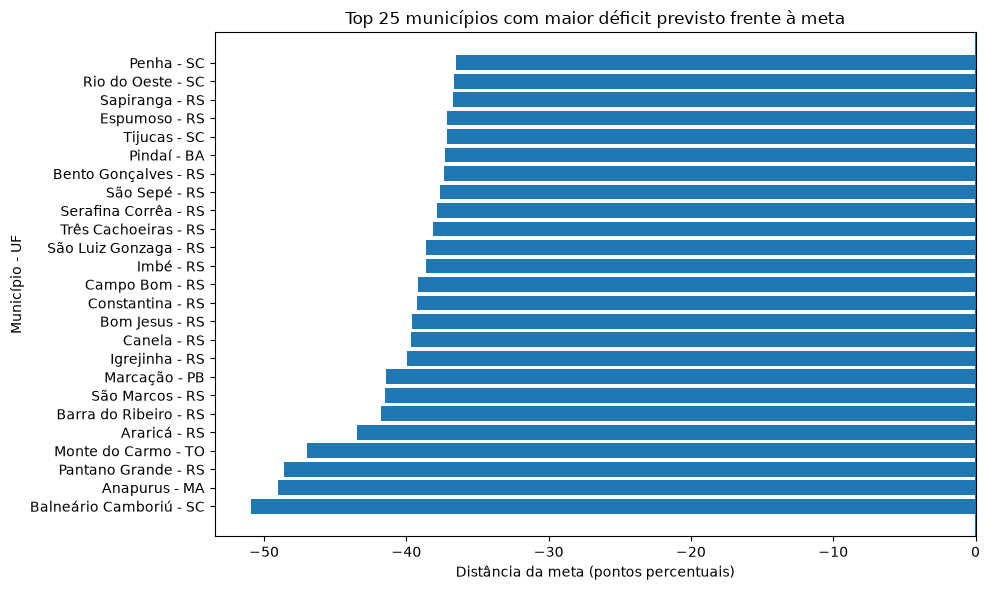

In [216]:
import matplotlib.pyplot as plt

# Pega município + UF
municipio_uf = (
    df_meta_munic[
        ["CO_MUNICIPIO", "SG_UF"]
    ]
    .drop_duplicates("CO_MUNICIPIO")
)

top25_risco = (
    risco_prioritario
    .sort_values("DISTANCIA_META")
    .head(25)
    .copy()
)

# Adiciona SG_UF
top25_risco = top25_risco.merge(
    municipio_uf,
    on="CO_MUNICIPIO",
    how="left"
)

# Cria rótulo Município - UF
top25_risco["MUNICIPIO_UF"] = (
    top25_risco["NO_MUNICIPIO"] + " - " +
    top25_risco["SG_UF"]
)

top25_risco = top25_risco.sort_values(
    "DISTANCIA_META",
    ascending=True
)

# Gráfico
plt.figure(figsize=(10, 6))

plt.barh(
    top25_risco["MUNICIPIO_UF"],
    top25_risco["DISTANCIA_META"]
)

plt.xlabel("Distância da meta (pontos percentuais)")
plt.ylabel("Município - UF")
plt.title("Top 25 municípios com maior déficit previsto frente à meta")

plt.axvline(0)

plt.tight_layout()
plt.show()

In [217]:
#Random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(
    X_train,
    y_train
)

prob_rf = modelo_rf.predict_proba(X_test)[:, 1]
pred_rf = (prob_rf >= 0.50).astype(int)

print("RANDOM FOREST")
print("=" * 40)
print(f"ROC-AUC:  {roc_auc_score(y_test, prob_rf):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, pred_rf):.4f}")
print(f"F1-score:  {f1_score(y_test, pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, pred_rf))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, pred_rf))

RANDOM FOREST
ROC-AUC:  0.6280
Accuracy: 0.6027
Precision: 0.6346
Recall:    0.7598
F1-score:  0.6916

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.38      0.44    919754
           1       0.63      0.76      0.69   1303038

    accuracy                           0.60   2222792
   macro avg       0.58      0.57      0.57   2222792
weighted avg       0.59      0.60      0.59   2222792


Matriz de Confusão:
[[349596 570158]
 [312950 990088]]


| Métrica     | Random Forest |   LightGBM |
| ----------- | ------------: | ---------: |
| **ROC-AUC** |        0,6280 | **0,6333** |
| Accuracy    |        0,6027 |     0,6000 |
| Precision   |        0,6346 |      0,66* |
| Recall      |        0,7598 |      0,66* |
| F1          |    **0,6916** |      0,66* |

Random Forest

bom modelo de referência;
captura relações não lineares;
apresentou F1 interessante;
porém tem dificuldade maior em separar os alunos não alfabetizados.

LightGBM

teve ROC-AUC um pouco superior: 0,6333 vs. 0,6280;
portanto, apresentou melhor capacidade geral de discriminação;
é o modelo que estamos usando como principal para a etapa de risco.

In [218]:
#XGBoost
# Preparar os dados para o XGBoost, convertendo as colunas categóricas em códigos numéricos
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

for col in CATEGORICAS:
    X_train_xgb[col] = X_train_xgb[col].cat.codes
    X_test_xgb[col] = X_test_xgb[col].cat.codes


In [219]:
#treinar o modelo XGBoost
modelo_xgb = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

modelo_xgb.fit(
    X_train_xgb,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [220]:
#previsões e avaliação do modelo XGBoost
prob_xgb = modelo_xgb.predict_proba(X_test_xgb)[:, 1]

pred_xgb = (prob_xgb >= 0.50).astype(int)

In [221]:
#avaliação do modelo XGBoost
print("XGBOOST")
print("=" * 40)

print(f"ROC-AUC:  {roc_auc_score(y_test, prob_xgb):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, pred_xgb):.4f}")
print(f"F1-score:  {f1_score(y_test, pred_xgb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, pred_xgb))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, pred_xgb))


XGBOOST
ROC-AUC:  0.6290
Accuracy: 0.6037
Precision: 0.6497
Recall:    0.7031
F1-score:  0.6753

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.46      0.49    919754
           1       0.65      0.70      0.68   1303038

    accuracy                           0.60   2222792
   macro avg       0.59      0.58      0.58   2222792
weighted avg       0.60      0.60      0.60   2222792


Matriz de Confusão:
[[425788 493966]
 [386929 916109]]


In [222]:
prob_lgb = modelo_lgb.predict_proba(X_test)[:, 1]
pred_lgb = (prob_lgb >= 0.50).astype(int)

print("LIGHTGBM")
print("=" * 40)

print(f"ROC-AUC:  {roc_auc_score(y_test, prob_lgb):.4f}")
print(f"Accuracy: {accuracy_score(y_test, pred_lgb):.4f}")
print(f"Precision: {precision_score(y_test, pred_lgb):.4f}")
print(f"Recall:    {recall_score(y_test, pred_lgb):.4f}")
print(f"F1-score:  {f1_score(y_test, pred_lgb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, pred_lgb))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, pred_lgb))

LIGHTGBM
ROC-AUC:  0.6333
Accuracy: 0.6032
Precision: 0.6623
Recall:    0.6594
F1-score:  0.6608

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.52      0.52    919754
           1       0.66      0.66      0.66   1303038

    accuracy                           0.60   2222792
   macro avg       0.59      0.59      0.59   2222792
weighted avg       0.60      0.60      0.60   2222792


Matriz de Confusão:
[[481553 438201]
 [443765 859273]]


| Modelo        |    ROC-AUC |   Accuracy |  Precision |     Recall |         F1 |
| ------------- | ---------: | ---------: | ---------: | ---------: | ---------: |
| Random Forest |     0,6280 |     0,6027 |     0,6346 | **0,7598** | **0,6916** |
| XGBoost       |     0,6290 | **0,6037** |     0,6497 |     0,7031 |     0,6753 |
| **LightGBM**  | **0,6333** |     0,6032 | **0,6623** |     0,6594 |     0,6608 |

🌳 Random Forest

Maior Recall (75,98%) para alfabetizados.
Porém, classificou muitos alunos como alfabetizados que na realidade não eram.
Serve bem como modelo de referência/baseline.

🚀 XGBoost

Accuracy ligeiramente maior (60,37%).
ROC-AUC de 0,6290, praticamente empatado com Random Forest.
Não apresentou ganho relevante de discriminação.

⚡ LightGBM — modelo escolhido

Melhor ROC-AUC: 0,6333.
Melhor Precision: 66,23%.
Accuracy muito próxima do XGBoost.
Apresenta um equilíbrio mais interessante entre Precision e Recall.

Os três modelos apresentaram desempenho semelhante. O LightGBM obteve o maior ROC-AUC (0,6333) e a maior precisão (0,6623), apresentando o melhor equilíbrio para a etapa de identificação de risco. Por isso, foi selecionado como modelo final.


APRESENTAÇÃO

Podemos fazer a apresentação de forma dinâmica:

1️⃣ Random Forest
“Começamos com um modelo robusto baseado em árvores.”

⬇️

2️⃣ XGBoost
“Testamos boosting para verificar se conseguiríamos aumentar a capacidade preditiva.”

⬇️

3️⃣ LightGBM
“Testamos uma implementação mais eficiente de boosting e obtivemos o melhor ROC-AUC.”

⬇️

4️⃣ Modelo final
LightGBM → análise de risco → municípios → metas de alfabetização.

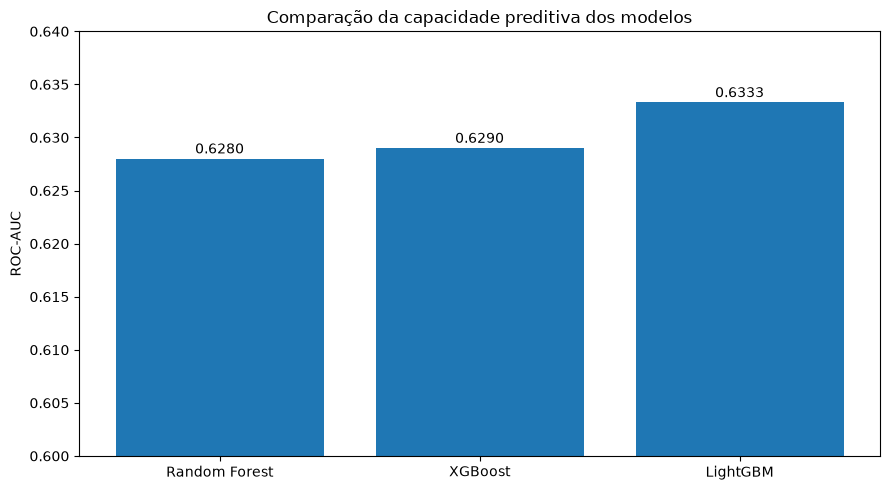

In [223]:
import matplotlib.pyplot as plt

modelos = ["Random Forest", "XGBoost", "LightGBM"]
roc_auc = [0.6280, 0.6290, 0.6333]

plt.figure(figsize=(9, 5))
plt.bar(modelos, roc_auc)

plt.ylabel("ROC-AUC")
plt.title("Comparação da capacidade preditiva dos modelos")
plt.ylim(0.60, 0.64)

for i, valor in enumerate(roc_auc):
    plt.text(i, valor + 0.0005, f"{valor:.4f}", ha="center")

plt.tight_layout()
plt.show()

Os três modelos apresentaram desempenho semelhante, com leve vantagem do LightGBM, que atingiu ROC-AUC de 0,6333.

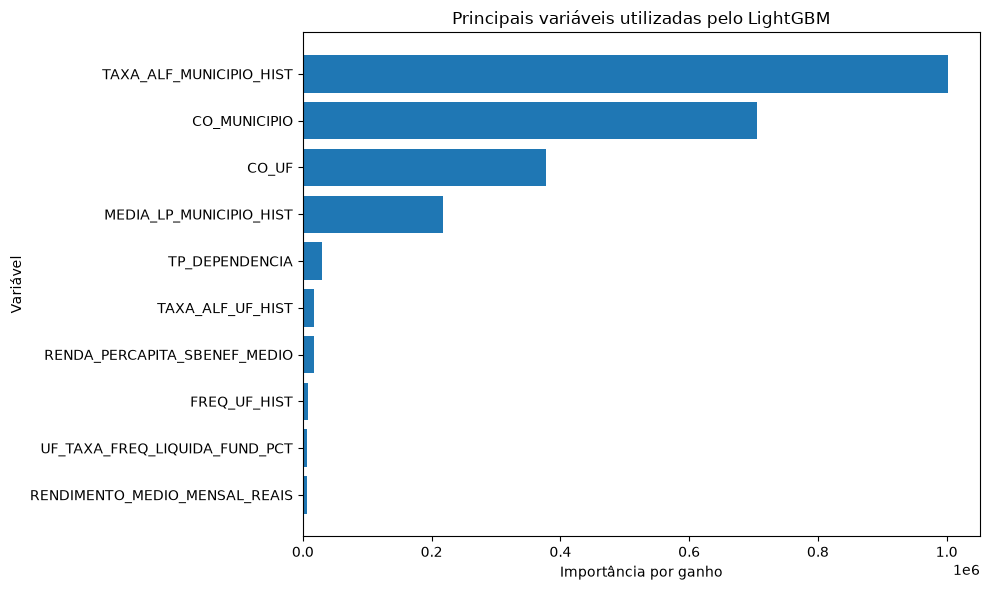

In [ ]:
importancias = pd.DataFrame({
    "FEATURE": modelo_lgb.booster_.feature_name(),
    "IMPORTANCIA": modelo_lgb.booster_.feature_importance(
        importance_type="gain"
    )
})

top_features = (
    importancias
    .sort_values("IMPORTANCIA", ascending=False)
    .head(10)
    .sort_values("IMPORTANCIA")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["FEATURE"],
    top_features["IMPORTANCIA"]
)

plt.xlabel("Importância por ganho")
plt.ylabel("Variável")
plt.title("Principais variáveis utilizadas pelo LightGBM")

plt.tight_layout()
plt.show()

O histórico educacional do município é o principal sinal utilizado pelo modelo para prever a alfabetização.

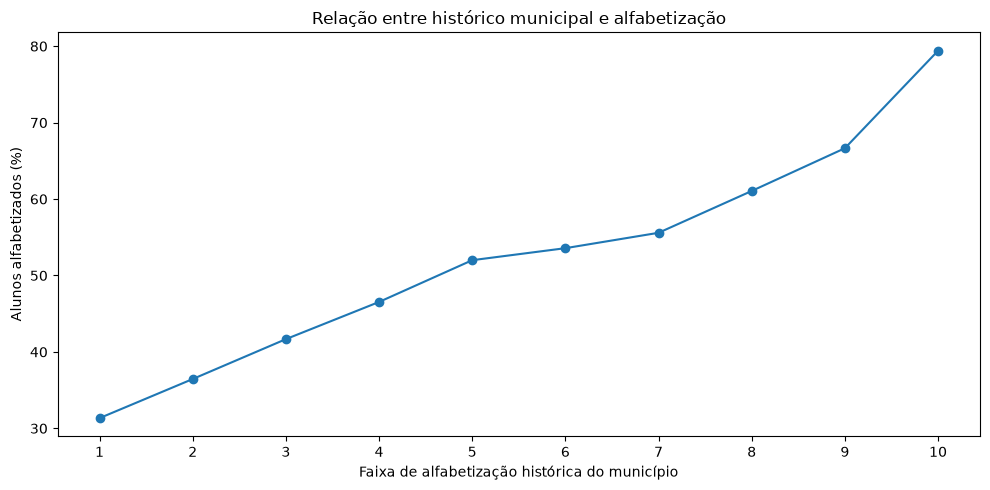

In [225]:
analise_decis = (
    df_train
    .groupby(
        pd.qcut(
            df_train["TAXA_ALF_MUNICIPIO_HIST"],
            q=10,
            duplicates="drop"
        ),
        observed=True
    )["IN_ALFABETIZADO"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(analise_decis) + 1),
    analise_decis["IN_ALFABETIZADO"],
    marker="o"
)

plt.xlabel("Faixa de alfabetização histórica do município")
plt.ylabel("Alunos alfabetizados (%)")
plt.title("Relação entre histórico municipal e alfabetização")

plt.xticks(range(1, 11))

plt.tight_layout()
plt.show()

Quanto maior o histórico de alfabetização do município, maior tende a ser a taxa de alfabetização observada no período seguinte.
Esse gráfico ajuda a justificar por que TAXA_ALF_MUNICIPIO_HIST apareceu como principal variável do modelo.

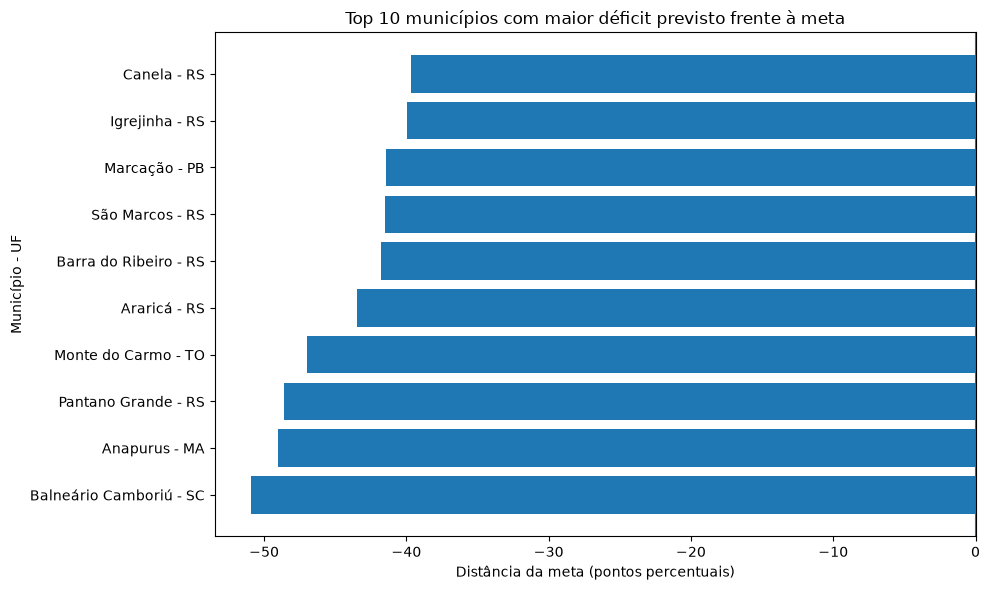

In [226]:
top10_risco = (
    risco_prioritario
    .sort_values("DISTANCIA_META")
    .head(10)
    .copy()
)

municipio_uf = (
    df_meta_munic[
        ["CO_MUNICIPIO", "SG_UF"]
    ]
    .drop_duplicates("CO_MUNICIPIO")
)

top10_risco = top10_risco.merge(
    municipio_uf,
    on="CO_MUNICIPIO",
    how="left"
)

top10_risco["MUNICIPIO_UF"] = (
    top10_risco["NO_MUNICIPIO"]
    + " - "
    + top10_risco["SG_UF"]
)

top10_risco = top10_risco.sort_values(
    "DISTANCIA_META",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_risco["MUNICIPIO_UF"],
    top10_risco["DISTANCIA_META"]
)

plt.xlabel("Distância da meta (pontos percentuais)")
plt.ylabel("Município - UF")
plt.title(
    "Top 10 municípios com maior déficit previsto frente à meta"
)

plt.axvline(0)

plt.tight_layout()
plt.show()

O modelo permite priorizar municípios cuja previsão de alfabetização está abaixo da meta estabelecida para 2025

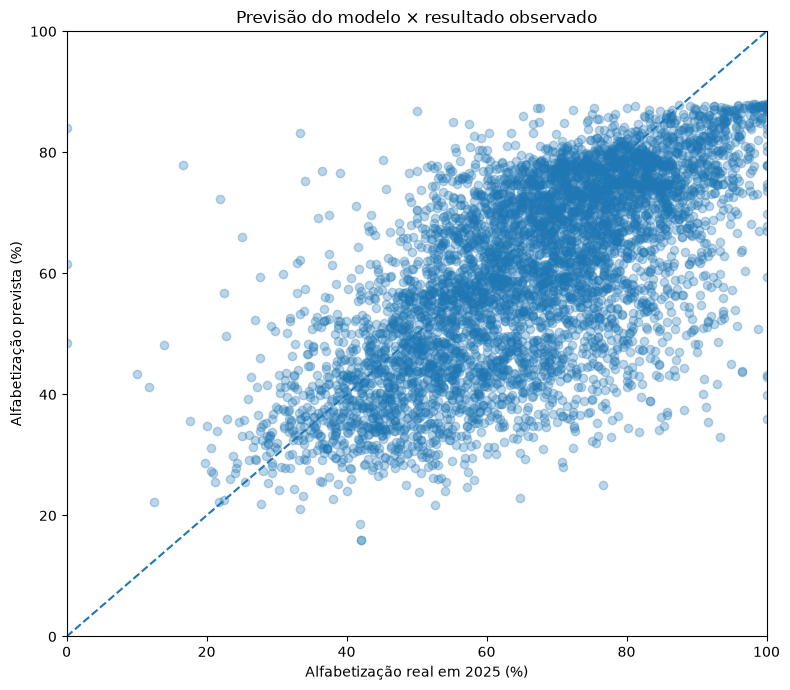

In [227]:
plt.figure(figsize=(8, 7))

plt.scatter(
    analise_risco_final["REAL_PCT"],
    analise_risco_final["PREVISTA_PCT"],
    alpha=0.3
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Alfabetização real em 2025 (%)")
plt.ylabel("Alfabetização prevista (%)")
plt.title("Previsão do modelo × resultado observado")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

Previsão × realidade
O modelo consegue capturar o padrão geral, mas apresenta dispersão considerável nas previsões municipais.

MAE = 12,64 p.p.
RMSE = 16,54 p.p.
erro médio = −8,42 p.p.

Ou seja: O modelo não é um previsor preciso da taxa municipal, mas ferramenta de identificação e priorização de risco.

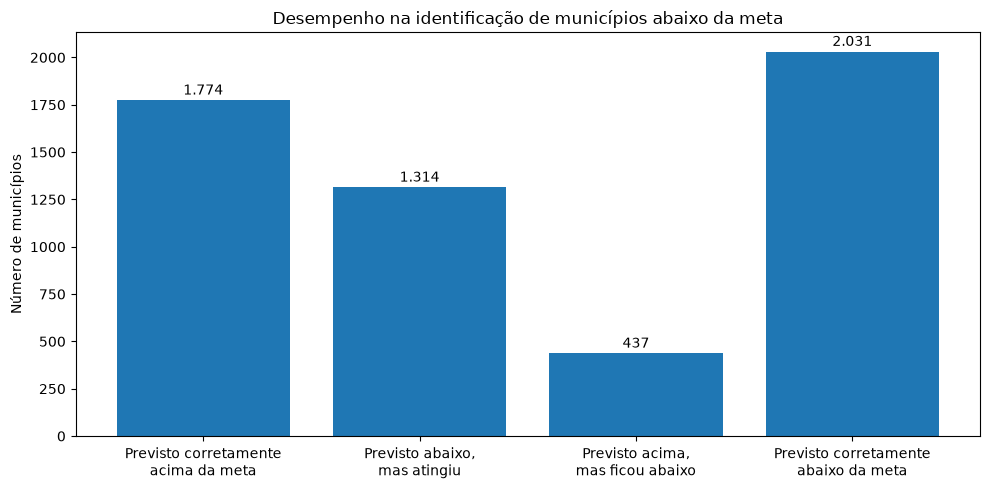

In [228]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    analise_risco_final["REAL_ABAIXO_META"],
    analise_risco_final["PREVISTO_ABAIXO_META"]
)

categorias = [
    "Atingiu meta",
    "Abaixo da meta"
]

# Verdadeiros positivos/negativos para a apresentação
valores = [
    cm[0, 0],
    cm[0, 1],
    cm[1, 0],
    cm[1, 1]
]

nomes = [
    "Previsto corretamente\nacima da meta",
    "Previsto abaixo,\nmas atingiu",
    "Previsto acima,\nmas ficou abaixo",
    "Previsto corretamente\nabaixo da meta"
]

plt.figure(figsize=(10, 5))

plt.bar(nomes, valores)

plt.ylabel("Número de municípios")
plt.title("Desempenho na identificação de municípios abaixo da meta")

for i, valor in enumerate(valores):
    plt.text(i, valor + 30, f"{valor:,}".replace(",", "."), ha="center")

plt.tight_layout()
plt.show()

Resultado final: atingimento das metas

E finalmente chegamos ao gráfico que fecha a história.

Temos:

68,48% de acurácia

e, principalmente:

82% de sensibilidade para municípios que ficaram abaixo da meta.

Conclusões

1. O histórico educacional é determinante

A taxa histórica de alfabetização municipal foi a principal variável utilizada pelo modelo.

2. O LightGBM apresentou o melhor desempenho

ROC-AUC de 0,6333, superando marginalmente Random Forest e XGBoost.

3. O modelo é mais útil para identificar risco do que para prever uma taxa exata

MAE municipal de 12,64 pontos percentuais indica limitações para previsões pontuais.

4. A abordagem consegue apoiar a priorização territorial

Na avaliação 2024 → 2025, o modelo identificou corretamente 82% dos municípios que ficaram abaixo da meta.

5. Aplicação prática

A solução pode apoiar gestores na identificação antecipada de municípios prioritários, direcionando acompanhamento e políticas educacionais.


Mais do que prever um resultado, o modelo busca antecipar onde está o risco e apoiar a priorização das ações educacionais.